Going with Cruise

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [306]:
random_df = pd.read_csv("D:\C_drive_Folders\Rishikh\matterwithin\Fuel_consumption\Fuel_consumption.csv")
print(random_df['FQTY_3'].unique())
random_df.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\HP\AppData\Local\Temp\ipykernel_24864\4213056106.py:1: SyntaxWarning: invalid escape sequence '\C'
  random_df = pd.read_csv("D:\C_drive_Folders\Rishikh\matterwithin\Fuel_consumption\Fuel_consumption.csv")


[0]


,Unnamed: 0,Flight_instance_ID,Year,Month,Day,Hour,Minute,Second,ABRK,ELEV_1,...,BPGR_2,BPYR_1,BPYR_2,CALT,CASS,CRSS,DFGS,DWPT,EAI,FF
0,676,6.762000e+14,2004,5,20,12,42,36,119.983559,24.036133,...,48.828247,58.593899,0,0,135.0,-158.026213,1,27808,0,0
1,676,6.762000e+14,2004,5,20,12,42,37,119.983559,24.015671,...,43.945423,58.593899,0,0,135.0,-158.026213,1,27808,0,0
2,676,6.762000e+14,2004,5,20,12,42,38,119.983559,24.036133,...,43.945423,58.593899,0,0,135.0,-158.026213,1,27808,0,0
3,676,6.762000e+14,2004,5,20,12,42,39,119.983559,24.036133,...,48.828247,58.593899,0,0,135.0,-158.026213,1,27808,0,0
4,676,6.762000e+14,2004,5,20,12,42,40,119.983559,24.056587,...,43.945423,58.593899,0,0,135.0,-158.026213,1,27808,0,0


In [307]:
# Find all columns containing the word 'Fuel'
keywords = 'FQTY'
matching_cols = [col for col in random_df.columns if keywords in col]

print(matching_cols)
print(random_df[matching_cols[0]].nunique())
print(random_df[matching_cols[1]].nunique())
print(random_df[matching_cols[2]].nunique())
print(random_df[matching_cols[3]].nunique())
random_df['FQTY_1'].value_counts(), random_df['FQTY_2'].value_counts(), random_df['FQTY_3'].value_counts(), random_df['FQTY_4'].value_counts()

['FQTY_1', 'FQTY_2', 'FQTY_3', 'FQTY_4']
540
1
1
547


(FQTY_1
 7624    87
 3432    87
 3752    48
 7616    47
 7488    45
         ..
 7160     1
 7312     1
 7128     1
 7216     1
 7344     1
 Name: count, Length: 540, dtype: int64,
 FQTY_2
 0    6564
 Name: count, dtype: int64,
 FQTY_3
 0    6564
 Name: count, dtype: int64,
 FQTY_4
 7600    149
 3304     58
 3296     55
 3608     46
 7504     46
        ... 
 5704      1
 7352      1
 7328      1
 7288      1
 4464      1
 Name: count, Length: 547, dtype: int64)

In [308]:
random_df.describe()

,Unnamed: 0,Flight_instance_ID,Year,Month,Day,Hour,Minute,Second,ABRK,ELEV_1,...,BPGR_2,BPYR_1,BPYR_2,CALT,CASS,CRSS,DFGS,DWPT,EAI,FF
count,6564.0,6.564000e+03,6564.0,6564.0,6564.0,6564.000000,6564.000000,6564.000000,6564.000000,6564.000000,...,6564.000000,6564.000000,6564.0,6564.0,6564.000000,6.564000e+03,6564.0,6564.000000,6564.000000,6564.000000
mean,676.0,6.762000e+14,2004.0,5.0,20.0,13.133455,28.791590,29.565814,118.927441,-1.812411,...,27.504200,151.095311,0.0,0.0,245.274413,-1.580262e+02,1.0,124240.831200,8.001980,4637.207191
std,0.0,0.000000e+00,0.0,0.0,0.0,0.658642,17.956433,17.326896,6.919525,8.155437,...,9.778876,505.846783,0.0,0.0,59.836500,2.524040e-11,0.0,137443.859292,1.720841,2102.585282
min,676.0,6.762000e+14,2004.0,5.0,20.0,12.000000,0.000000,0.000000,60.000000,-41.900002,...,0.000000,0.000000,0.0,0.0,113.000000,-1.580262e+02,1.0,0.000000,0.000000,0.000000
25%,676.0,6.762000e+14,2004.0,5.0,20.0,13.000000,13.000000,15.000000,119.983559,-5.136974,...,19.531300,48.828247,0.0,0.0,243.250000,-1.580262e+02,1.0,18880.000000,8.000000,2830.000000
50%,676.0,6.762000e+14,2004.0,5.0,20.0,13.000000,27.000000,30.000000,119.983559,-3.234383,...,24.414124,48.828247,0.0,0.0,280.000000,-1.580262e+02,1.0,51608.000000,8.000000,5032.000000
75%,676.0,6.762000e+14,2004.0,5.0,20.0,14.000000,46.000000,45.000000,119.983559,-1.945526,...,34.179775,53.711075,0.0,0.0,286.750000,-1.580262e+02,1.0,196937.000000,8.000000,5744.000000
max,676.0,6.762000e+14,2004.0,5.0,20.0,14.000000,59.000000,59.000000,119.983559,24.138420,...,58.593899,3129.890869,0.0,0.0,298.000000,-1.580262e+02,1.0,444672.000000,15.000000,10020.000000


Removing columns having zero variance from single-flight all-phases dataset and adding Timestamp

In [312]:
random_df['Timestamp'] = pd.to_datetime(random_df[['Year','Month','Day','Hour','Minute','Second']])
def drop_unnecessary_columns(df):
    df.drop(columns = ['Year','Month','Day','Hour','Minute','Second'], inplace=True)
    numeric_columns = df.select_dtypes(include = ['int64','float64']).columns
    variance_0_columns = [column for column in numeric_columns if df[column].var()==0 and column != 'Flight_instance_ID' and column != 'ACID']
    df.drop(columns = variance_0_columns, inplace=True)
    return df, variance_0_columns
random_df, variance_0_columns = drop_unnecessary_columns(random_df)
random_df.head()

,Flight_instance_ID,ABRK,ELEV_1,ELEV_2,FGC3,FLAP,FQTY_1,FQTY_4,GLS,HDGS,...,APFD,BLV,BPGR_2,BPYR_1,CASS,CRSS,DWPT,EAI,FF,Timestamp
0,6.762000e+14,119.983559,24.036133,59.841667,120,94,7624,7608,-0.00078,-145.018492,...,2,0,48.828247,58.593899,135.0,-158.026213,27808,0,0,2004-05-20 12:42:36
1,6.762000e+14,119.983559,24.015671,59.862125,120,94,7624,7600,-0.00156,-145.018492,...,2,0,43.945423,58.593899,135.0,-158.026213,27808,0,0,2004-05-20 12:42:37
2,6.762000e+14,119.983559,24.036133,59.841667,120,94,7624,7600,-0.00156,-145.018492,...,2,0,43.945423,58.593899,135.0,-158.026213,27808,0,0,2004-05-20 12:42:38
3,6.762000e+14,119.983559,24.036133,59.821209,120,94,7624,7608,-0.00156,-145.018492,...,2,0,48.828247,58.593899,135.0,-158.026213,27808,0,0,2004-05-20 12:42:39
4,6.762000e+14,119.983559,24.056587,59.821209,120,94,7624,7608,-0.00156,-145.018492,...,2,0,43.945423,58.593899,135.0,-158.026213,27808,0,0,2004-05-20 12:42:40


In [313]:
variance_0_columns

['Unnamed: 0',
 'EVNT',
 'FADF',
 'FADS',
 'FIRE_1',
 'FIRE_2',
 'FIRE_3',
 'FIRE_4',
 'FQTY_2',
 'FQTY_3',
 'GPWS',
 'HF1',
 'HF2',
 'ILSF',
 'POVT',
 'PUSH',
 'SMKB',
 'SMOK',
 'SNAP',
 'TCAS',
 'TMAG',
 'WAI_1',
 'WAI_2',
 'APUF_Mean',
 'APUF_Min',
 'APUF_Max',
 'TOCW_Mean',
 'TOCW_Min',
 'TOCW_Max',
 'A_T',
 'BPGR_1',
 'BPYR_2',
 'CALT',
 'DFGS']

In [315]:
print(len(random_df.columns))
print(list(random_df.columns))
phase_encodings = {0:'unknown', 1:'preflight', 2:'taxi', 3:'takeoff', 4:'climb', 5:'cruise',6:'approach', 7:'rollout'}
phase_encodings, random_df['PH'].unique(), random_df['PH'].value_counts()

187
['Flight_instance_ID', 'ABRK', 'ELEV_1', 'ELEV_2', 'FGC3', 'FLAP', 'FQTY_1', 'FQTY_4', 'GLS', 'HDGS', 'HYDG', 'HYDY', 'LATP', 'LMOD', 'LOC', 'LONP', 'MNS', 'MRK', 'MW', 'N1CO', 'OIPL', 'OIT_1', 'OIT_2', 'OIT_3', 'OIT_4', 'PACK', 'PH', 'PTRM', 'SAT', 'SPLG', 'SPLY', 'SPL_1', 'SPL_2', 'TAI', 'TAT', 'TMODE', 'VHF1', 'VHF2', 'VHF3', 'VMODE', 'VSPS', 'CCPC_Mean', 'CCPC_Min', 'CCPC_Max', 'CCPF_Mean', 'CCPF_Min', 'CCPF_Max', 'CWPC_Mean', 'CWPC_Min', 'CWPC_Max', 'CWPF_Mean', 'CWPF_Min', 'CWPF_Max', 'MSQT_1_Mean', 'MSQT_1_Min', 'MSQT_1_Max', 'MSQT_2_Mean', 'MSQT_2_Min', 'MSQT_2_Max', 'PI_Mean', 'PI_Min', 'PI_Max', 'PS_Mean', 'PS_Min', 'PS_Max', 'PSA_Mean', 'PSA_Min', 'PSA_Max', 'PT_Mean', 'PT_Min', 'PT_Max', 'RUDD_Mean', 'RUDD_Min', 'RUDD_Max', 'RUDP_Mean', 'RUDP_Min', 'RUDP_Max', 'SHKR_Mean', 'SHKR_Min', 'SHKR_Max', 'ALT_Mean', 'ALT_Min', 'ALT_Max', 'ALTR_Mean', 'ALTR_Min', 'ALTR_Max', 'AOA1_Mean', 'AOA1_Min', 'AOA1_Max', 'AOA2_Mean', 'AOA2_Min', 'AOA2_Max', 'AOAC_Mean', 'AOAC_Min', 'AOAC_

({0: 'unknown',
  1: 'preflight',
  2: 'taxi',
  3: 'takeoff',
  4: 'climb',
  5: 'cruise',
  6: 'approach',
  7: 'rollout'},
 array([1, 2, 3, 4, 5, 6, 7], dtype=int64),
 PH
 5    2300
 4    2100
 6    1175
 2     825
 1     102
 3      35
 7      27
 Name: count, dtype: int64)

In [316]:
random_df['Phase_name'] = random_df['PH'].map(phase_encodings)
# Apply the map to the existing 'PH' column to create the new column
random_df['Phase_name'].value_counts()

Phase_name
cruise       2300
climb        2100
approach     1175
taxi          825
preflight     102
takeoff        35
rollout        27
Name: count, dtype: int64

In [317]:
random_df['FQTY_1'].value_counts(), random_df['FQTY_1'].var(), random_df['FQTY_4'].value_counts(), random_df['FQTY_4'].var()

(FQTY_1
 7624    87
 3432    87
 3752    48
 7616    47
 7488    45
         ..
 7160     1
 7312     1
 7128     1
 7216     1
 7344     1
 Name: count, Length: 540, dtype: int64,
 1807465.3547519436,
 FQTY_4
 7600    149
 3304     58
 3296     55
 3608     46
 7504     46
        ... 
 5704      1
 7352      1
 7328      1
 7288      1
 4464      1
 Name: count, Length: 547, dtype: int64,
 1926608.2914037441)

In [324]:
print(random_df['FQTY_1'].min())
print(random_df['FQTY_4'].min())
print(random_df['FQTY_1'].max())
print(random_df['FQTY_4'].max())
print(random_df.shape)

3240
3240
7648
7624
(6564, 188)


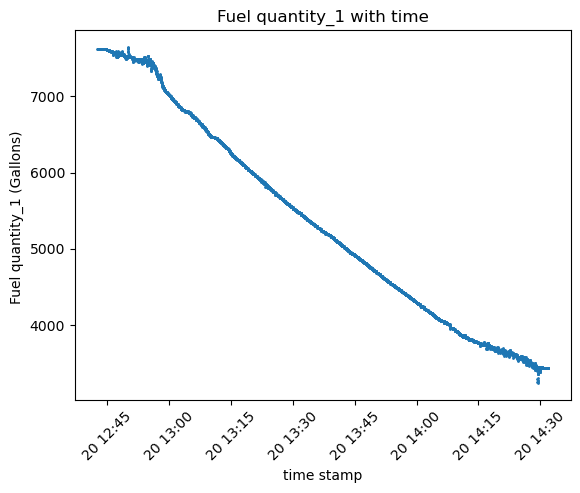

In [326]:
plt.scatter(random_df['Timestamp'], random_df['FQTY_1'], s=1)
plt.title("Fuel quantity_1 with time")
plt.xlabel("time stamp")
plt.xticks(rotation = 45)
plt.ylabel("Fuel quantity_1 (Gallons) ")
plt.show()

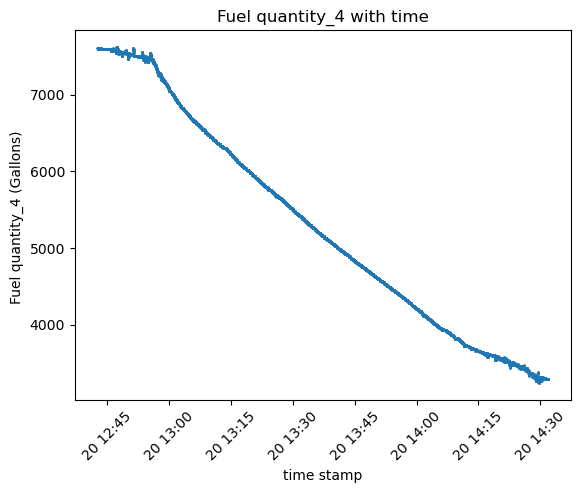

In [327]:
plt.scatter(random_df['Timestamp'], random_df['FQTY_4'], s=1)
plt.title("Fuel quantity_4 with time")
plt.xlabel("time stamp")
plt.xticks(rotation = 45)
plt.ylabel("Fuel quantity_4 (Gallons) ")
plt.show()

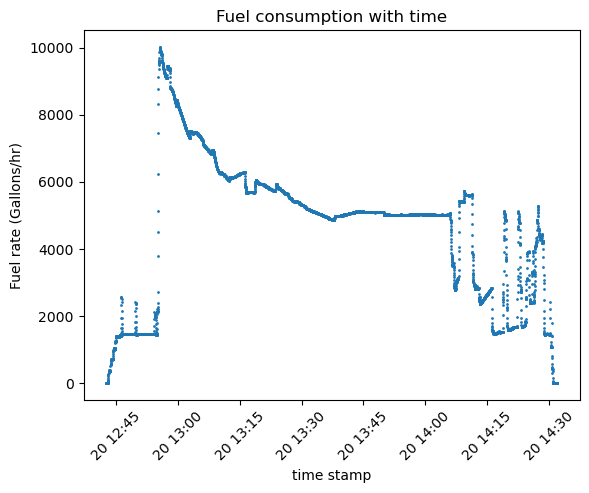

In [328]:
plt.scatter(random_df['Timestamp'], random_df['FF'], s=1)
plt.title("Fuel consumption with time")
plt.xlabel("time stamp")
plt.xticks(rotation = 45)
plt.ylabel("Fuel rate (Gallons/hr)")
plt.show()

In [329]:
random_df['Total_fuel'] = random_df['FQTY_1']+random_df['FQTY_4']
print(random_df['Total_fuel'].dtype)
print(random_df['FQTY_1'].dtype)
print(random_df['FQTY_4'].dtype)


int64
int64
int64


In [331]:
random_df['FF'].sum()

30438628

In [333]:
random_df['Total_fuel'].max()-random_df['Total_fuel'].min()

8624

'FF' is most likely Fuel flow(consumption) rate in Gallons/hour, 30438628 is sum of datapoints at all time instances.
'Total_fuel' is sum of fuel left/present in both tanks combined.
Total Physical Gallons Consumed = 8624

rate column is measured in Gallons per Hour. When using .sum() on all the rows, every single one of those rates is 3,600 times too large for a one-second window, final total sum (30,438,628) is also exactly 3,600 times too large. so dividing by 3600

30438628/3600 = 8455.17 Gallons, with 1.95% difference between this and 8624 Gallons.

In flight data analytics, this minor gap is fully expected and could be caused by:
Slightly variable sampling intervals (e.g., a data packet takes 1.02 seconds to record instead of exactly 1.00 seconds).
Fuel thermal expansion (Jet fuel changes volume/gallons as temperature shifts during flight, meaning the physical tank sensors and the engine flow meters will fluctuate slightly)


In [339]:
random_df['Flight_instance_ID'].unique(), random_df['Flight_instance_ID'].min(), random_df['Flight_instance_ID'].max(), random_df['Flight_instance_ID'].var()

(array([6.762e+14]), 676200000000000.0, 676200000000000.0, 0.0)

In [341]:
# reason for a massive number like 3466.7937776169433 instead of 0.0 is due to a floating-point precision limitation and
# internal rounding errors in computers, combined with the fact that values are extremely large 15-digit integers

# below methods prove that variance is indeed 0
is_constant = (random_df['Flight_instance_ID'] == 676200405201243).all()
print(is_constant)

variance = 0.0 if random_df['Flight_instance_ID'].nunique() <= 1 else random_df['column'].var()
print(variance)

False
0.0


Extracting 'Cruise' phase data from this single-flight dataframe 'random_df'

In [344]:
random_df_cruise =  random_df[random_df['PH']==5]  # making new dataframe of only cruise
random_df_cruise['fuel_consumed'] = random_df_cruise['Total_fuel'].max()-random_df_cruise['Total_fuel']
# can use groupby() when multiple groups have different max value
print( random_df_cruise.shape)
random_df_cruise.head()

(2300, 190)


C:\Users\HP\AppData\Local\Temp\ipykernel_24864\1684346585.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  random_df_cruise['fuel_consumed'] = random_df_cruise['Total_fuel'].max()-random_df_cruise['Total_fuel']


,Flight_instance_ID,ABRK,ELEV_1,ELEV_2,FGC3,FLAP,FQTY_1,FQTY_4,GLS,HDGS,...,BPYR_1,CASS,CRSS,DWPT,EAI,FF,Timestamp,Phase_name,Total_fuel,fuel_consumed
1826,6.762000e+14,119.983559,-6.916821,83.041039,24,95,6368,6320,-0.07995,-151.082914,...,53.711075,280.0,-158.026213,60768,8,6120,2004-05-20 13:13:02,cruise,12688,0
1827,6.762000e+14,60.000000,-5.607510,82.918289,24,94,6368,6320,-0.00039,-151.082914,...,48.828247,280.0,-158.026213,60764,8,6120,2004-05-20 13:13:03,cruise,12688,0
1828,6.762000e+14,119.983559,-5.505219,82.734169,24,94,6368,6320,-0.00039,-151.082914,...,53.711075,280.0,-158.026213,60760,8,6124,2004-05-20 13:13:04,cruise,12688,0
1829,6.762000e+14,119.983559,-4.564152,82.509132,24,94,6368,6320,-0.00039,-151.082914,...,48.828247,280.0,-158.026213,60756,8,6128,2004-05-20 13:13:05,cruise,12688,0
1830,6.762000e+14,119.983559,-3.766289,82.202263,24,94,6368,6320,-0.00117,-151.082914,...,53.711075,280.0,-158.026213,60752,8,6128,2004-05-20 13:13:06,cruise,12688,0


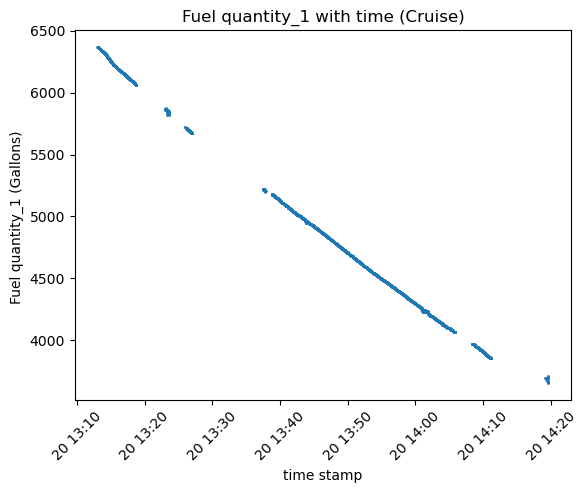

In [352]:
plt.scatter(random_df_cruise['Timestamp'], random_df_cruise['FQTY_1'], s=1)
plt.title("Fuel quantity_1 with time (Cruise)")
plt.xlabel("time stamp")
plt.xticks(rotation = 45)
plt.ylabel("Fuel quantity_1 (Gallons) ")
plt.show()

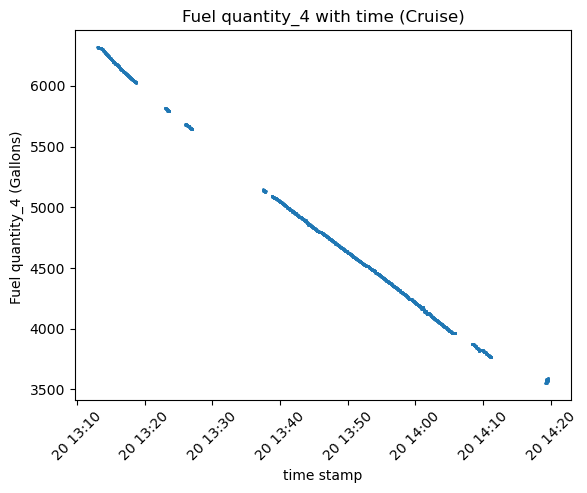

In [354]:
plt.scatter(random_df_cruise['Timestamp'], random_df_cruise['FQTY_4'], s=1)
plt.title("Fuel quantity_4 with time (Cruise)")
plt.xlabel("time stamp")
plt.xticks(rotation = 45)
plt.ylabel("Fuel quantity_4 (Gallons) ")
plt.show()

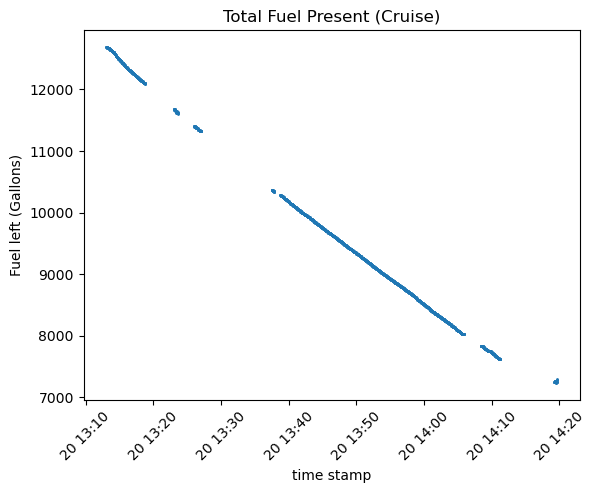

In [356]:
plt.scatter(random_df_cruise['Timestamp'], random_df_cruise['Total_fuel'], s=1)
plt.title("Total Fuel Present (Cruise)")
plt.xlabel("time stamp")
plt.xticks(rotation = 45)
plt.ylabel("Fuel left (Gallons)")
plt.show()

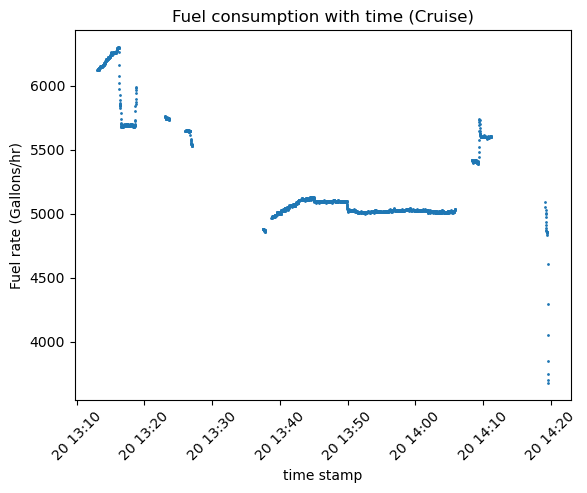

In [358]:
plt.scatter(random_df_cruise['Timestamp'], random_df_cruise['FF'], s=1)
plt.title("Fuel consumption with time (Cruise)")
plt.xlabel("time stamp")
plt.xticks(rotation = 45)
plt.ylabel("Fuel rate (Gallons/hr)")
plt.show()

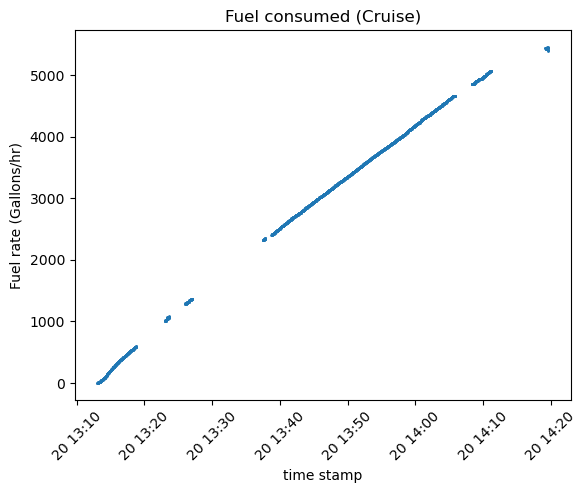

In [360]:
plt.scatter(random_df_cruise['Timestamp'], random_df_cruise['fuel_consumed'], s=1)
plt.title("Fuel consumed (Cruise)")
plt.xlabel("time stamp")
plt.xticks(rotation = 45)
plt.ylabel("Fuel rate (Gallons/hr)")
plt.show()

In [362]:
print(random_df_cruise['Total_fuel'].dtype)
print(random_df_cruise['FQTY_1'].dtype)
print(random_df_cruise['FQTY_4'].dtype)
print(random_df_cruise['fuel_consumed'].dtype)

int64
int64
int64
int64


In [364]:
random_df_cruise['FF'].sum()

12063852

In [366]:
random_df_cruise['Total_fuel'].max()-random_df_cruise['Total_fuel'].min()

5456

'FF' is most likely Fuel flow(consumption) rate in Gallons/hour, 12063852 is sum of datapoints at all time instances. 
'Total_fuel' is sum of fuel left/present in both tanks combined. 
Total Physical Gallons Consumed = 5456

In [369]:
initial_fuel = random_df_cruise['Total_fuel'].max()
final_fuel = random_df_cruise['Total_fuel'].min()
total_consumed = initial_fuel-final_fuel
total_consumed

5456

In [371]:
random_df_cruise['fuel_consumed'].sum()

7062384

In [373]:
random_df_cruise.head()

,Flight_instance_ID,ABRK,ELEV_1,ELEV_2,FGC3,FLAP,FQTY_1,FQTY_4,GLS,HDGS,...,BPYR_1,CASS,CRSS,DWPT,EAI,FF,Timestamp,Phase_name,Total_fuel,fuel_consumed
1826,6.762000e+14,119.983559,-6.916821,83.041039,24,95,6368,6320,-0.07995,-151.082914,...,53.711075,280.0,-158.026213,60768,8,6120,2004-05-20 13:13:02,cruise,12688,0
1827,6.762000e+14,60.000000,-5.607510,82.918289,24,94,6368,6320,-0.00039,-151.082914,...,48.828247,280.0,-158.026213,60764,8,6120,2004-05-20 13:13:03,cruise,12688,0
1828,6.762000e+14,119.983559,-5.505219,82.734169,24,94,6368,6320,-0.00039,-151.082914,...,53.711075,280.0,-158.026213,60760,8,6124,2004-05-20 13:13:04,cruise,12688,0
1829,6.762000e+14,119.983559,-4.564152,82.509132,24,94,6368,6320,-0.00039,-151.082914,...,48.828247,280.0,-158.026213,60756,8,6128,2004-05-20 13:13:05,cruise,12688,0
1830,6.762000e+14,119.983559,-3.766289,82.202263,24,94,6368,6320,-0.00117,-151.082914,...,53.711075,280.0,-158.026213,60752,8,6128,2004-05-20 13:13:06,cruise,12688,0


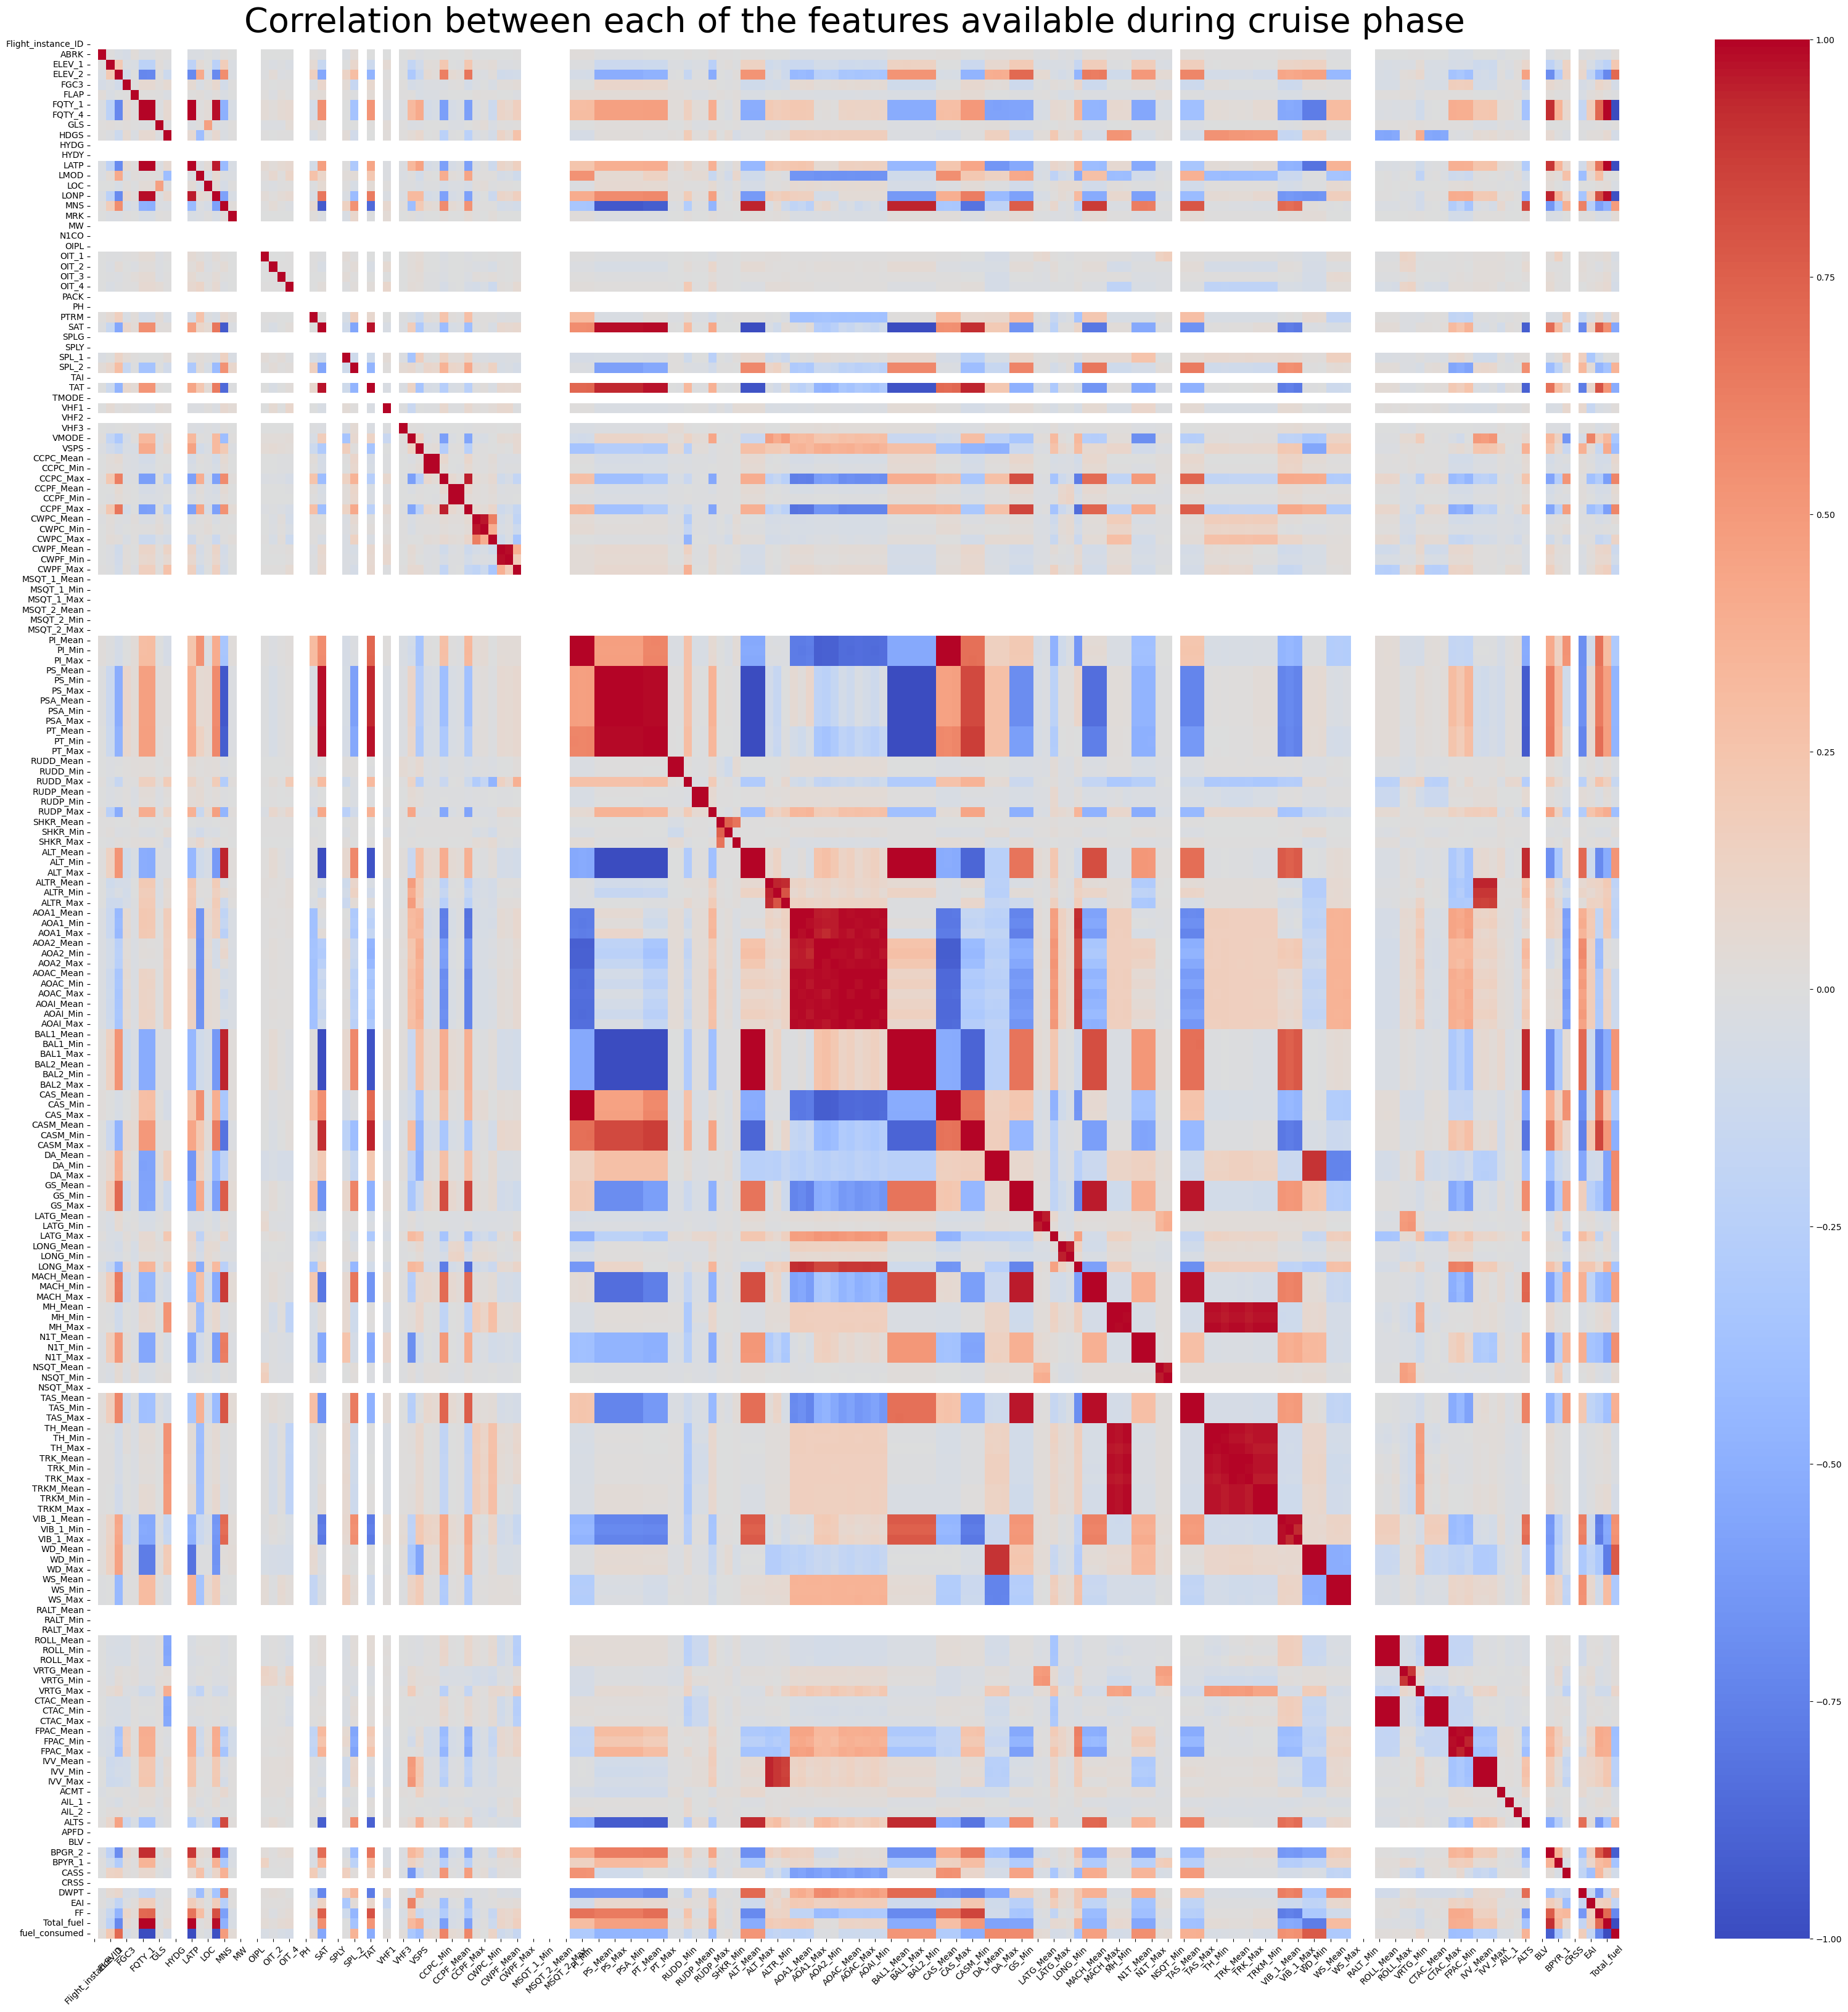

In [375]:
numeric_columns_dataset_cruise = random_df_cruise.select_dtypes(include = 'number')
# selects all columns containing int64, float64, int32, and other numerical types while automatically excluding text, dates, and booleans
numeric_columns_cruise = numeric_columns_dataset_cruise.columns
corr_matrix_cruise = numeric_columns_dataset_cruise.corr()
plt.figure(figsize=(40,40))
sns.heatmap(corr_matrix_cruise, cmap = 'coolwarm')
plt.title("Correlation between each of the features available during cruise phase", fontsize = 40)
plt.xticks(rotation=45)
plt.show()

In [377]:
numeric_columns_dataset_cruise.isnull().sum().sum() #returns a single number representing all missing values combined

0

In [379]:
random_df_cruise.shape

(2300, 190)

In [381]:
numeric_columns_dataset_cruise.shape

(2300, 188)

In [383]:
corr_matrix_cruise.shape

(188, 188)

In [385]:
if 'FF' in corr_matrix_cruise.columns:
    print("Found exact match for FF!")
    print(corr_matrix_cruise['FF'])
else:
    print("Not found exact 'FF'")

if 'FF' in random_df_cruise.columns:
    print("Found exact match for FF!")
    print(random_df_cruise['FF'].unique())
else:
    print("Not found exact 'FF'")

# Scaning all columns for the letters 'FF' (case-insensitive)
hidden_matches = [col for col in corr_matrix_cruise.columns if 'ff' in col.lower()]

print(f"Found {len(hidden_matches)} potential columns:")
print(hidden_matches)

Found exact match for FF!
Flight_instance_ID         NaN
ABRK                 -0.024868
ELEV_1               -0.151054
ELEV_2               -0.474161
FGC3                  0.106188
                        ...   
DWPT                 -0.634476
EAI                   0.152875
FF                    1.000000
Total_fuel            0.718287
fuel_consumed        -0.718287
Name: FF, Length: 188, dtype: float64
Found exact match for FF!
[6120 6124 6128 6122 6126 6138 6136 6144 6140 6142 6150 6148 6152 6146
 6158 6160 6162 6164 6166 6174 6176 6168 6182 6190 6192 6200 6208 6202
 6206 6204 6210 6222 6220 6214 6212 6216 6218 6224 6232 6242 6248 6252
 6260 6250 6240 6246 6254 6256 6264 6258 6262 6266 6272 6268 6280 6282
 6288 6286 6294 6296 6302 6300 6078 6022 5970 5926 5890 5868 5858 5850
 5842 5840 5824 5786 5742 5710 5702 5688 5678 5680 5684 5676 5674 5694
 5692 5686 5696 5690 5698 5704 5700 5682 5720 5732 5800 5854 5872 5898
 5944 5964 5980 5992 5764 5760 5752 5750 5746 5736 5738 5744 5748 5730
 

In [387]:
corr_values_with_FF = corr_matrix_cruise['FF']
corr_values_with_FF.values

array([            nan, -2.48681671e-02, -1.51053891e-01, -4.74160771e-01,
        1.06188144e-01,  4.10779169e-02,  7.16320336e-01,  7.20152486e-01,
        1.77393695e-04,  2.07971574e-02,             nan,             nan,
        6.65430526e-01,  2.92644904e-01,  1.92843700e-02,  8.07816190e-01,
       -5.88004835e-01, -4.13519125e-02,             nan,             nan,
                   nan,  1.68486275e-02, -1.92988225e-02,  1.88706929e-02,
        4.17780335e-02,             nan,             nan,  8.47319353e-02,
        7.55207074e-01,             nan,             nan, -1.02217947e-01,
       -4.56563990e-01,             nan,  7.99363901e-01,             nan,
       -4.36184887e-02,             nan, -3.93894697e-02,  1.84515445e-01,
       -1.51888197e-01, -7.31572455e-02, -6.29335468e-02, -2.86665601e-01,
       -6.67994992e-02, -5.40547268e-02, -3.11834088e-01, -5.47260855e-02,
       -9.51971672e-03, -1.60685699e-01,  9.96475108e-02,  7.83737030e-02,
        1.25647465e-01,  

In [389]:
# Returns True if 'Total' is in the dataset, otherwise False
is_numeric = 'Total_fuel' in numeric_columns_dataset_cruise.columns
print(is_numeric)

True


Below are the columns which have zero variance in this preflight part of dataset (these have non-zero variance in complete dataset hence were not dropped in earlier 0 var filtering)) and thus causing correlation to go NaN for their columns (Pearson rank corr coeff has denominator as variance thus any_number/0 gives NaN)

In [392]:
#variance0_preflight = [column for column in numeric_columns_dataset.columns if numeric_columns_dataset[column].var() == 0]
# doing by the first way was allowign 'FlightID'(var=1.00990099009901) & 'CRSS'(var=8.157915230546954e-26) 
# to go through, even though their nunique=1, so had to use another way
variance0_cruise = [col for col in numeric_columns_dataset_cruise.columns if numeric_columns_dataset_cruise[col].nunique() <= 1]
variance0_cruise, len(variance0_cruise)


(['Flight_instance_ID',
  'HYDG',
  'HYDY',
  'MW',
  'N1CO',
  'OIPL',
  'PACK',
  'PH',
  'SPLG',
  'SPLY',
  'TAI',
  'TMODE',
  'VHF2',
  'MSQT_1_Mean',
  'MSQT_1_Min',
  'MSQT_1_Max',
  'MSQT_2_Mean',
  'MSQT_2_Min',
  'MSQT_2_Max',
  'NSQT_Max',
  'RALT_Mean',
  'RALT_Min',
  'RALT_Max',
  'APFD',
  'BLV',
  'CRSS'],
 26)

Apart from ACID and PH, we can safely drop rest of the columns for this preflight regime
or
We can keep them and simply say they don't contribute in fuel consumption

In [395]:
random_df['SPLY'].nunique(), random_df_cruise['SPLY'].nunique()
# 2 different values in random_df but only single repeated value in random_df_preflight

(2, 1)

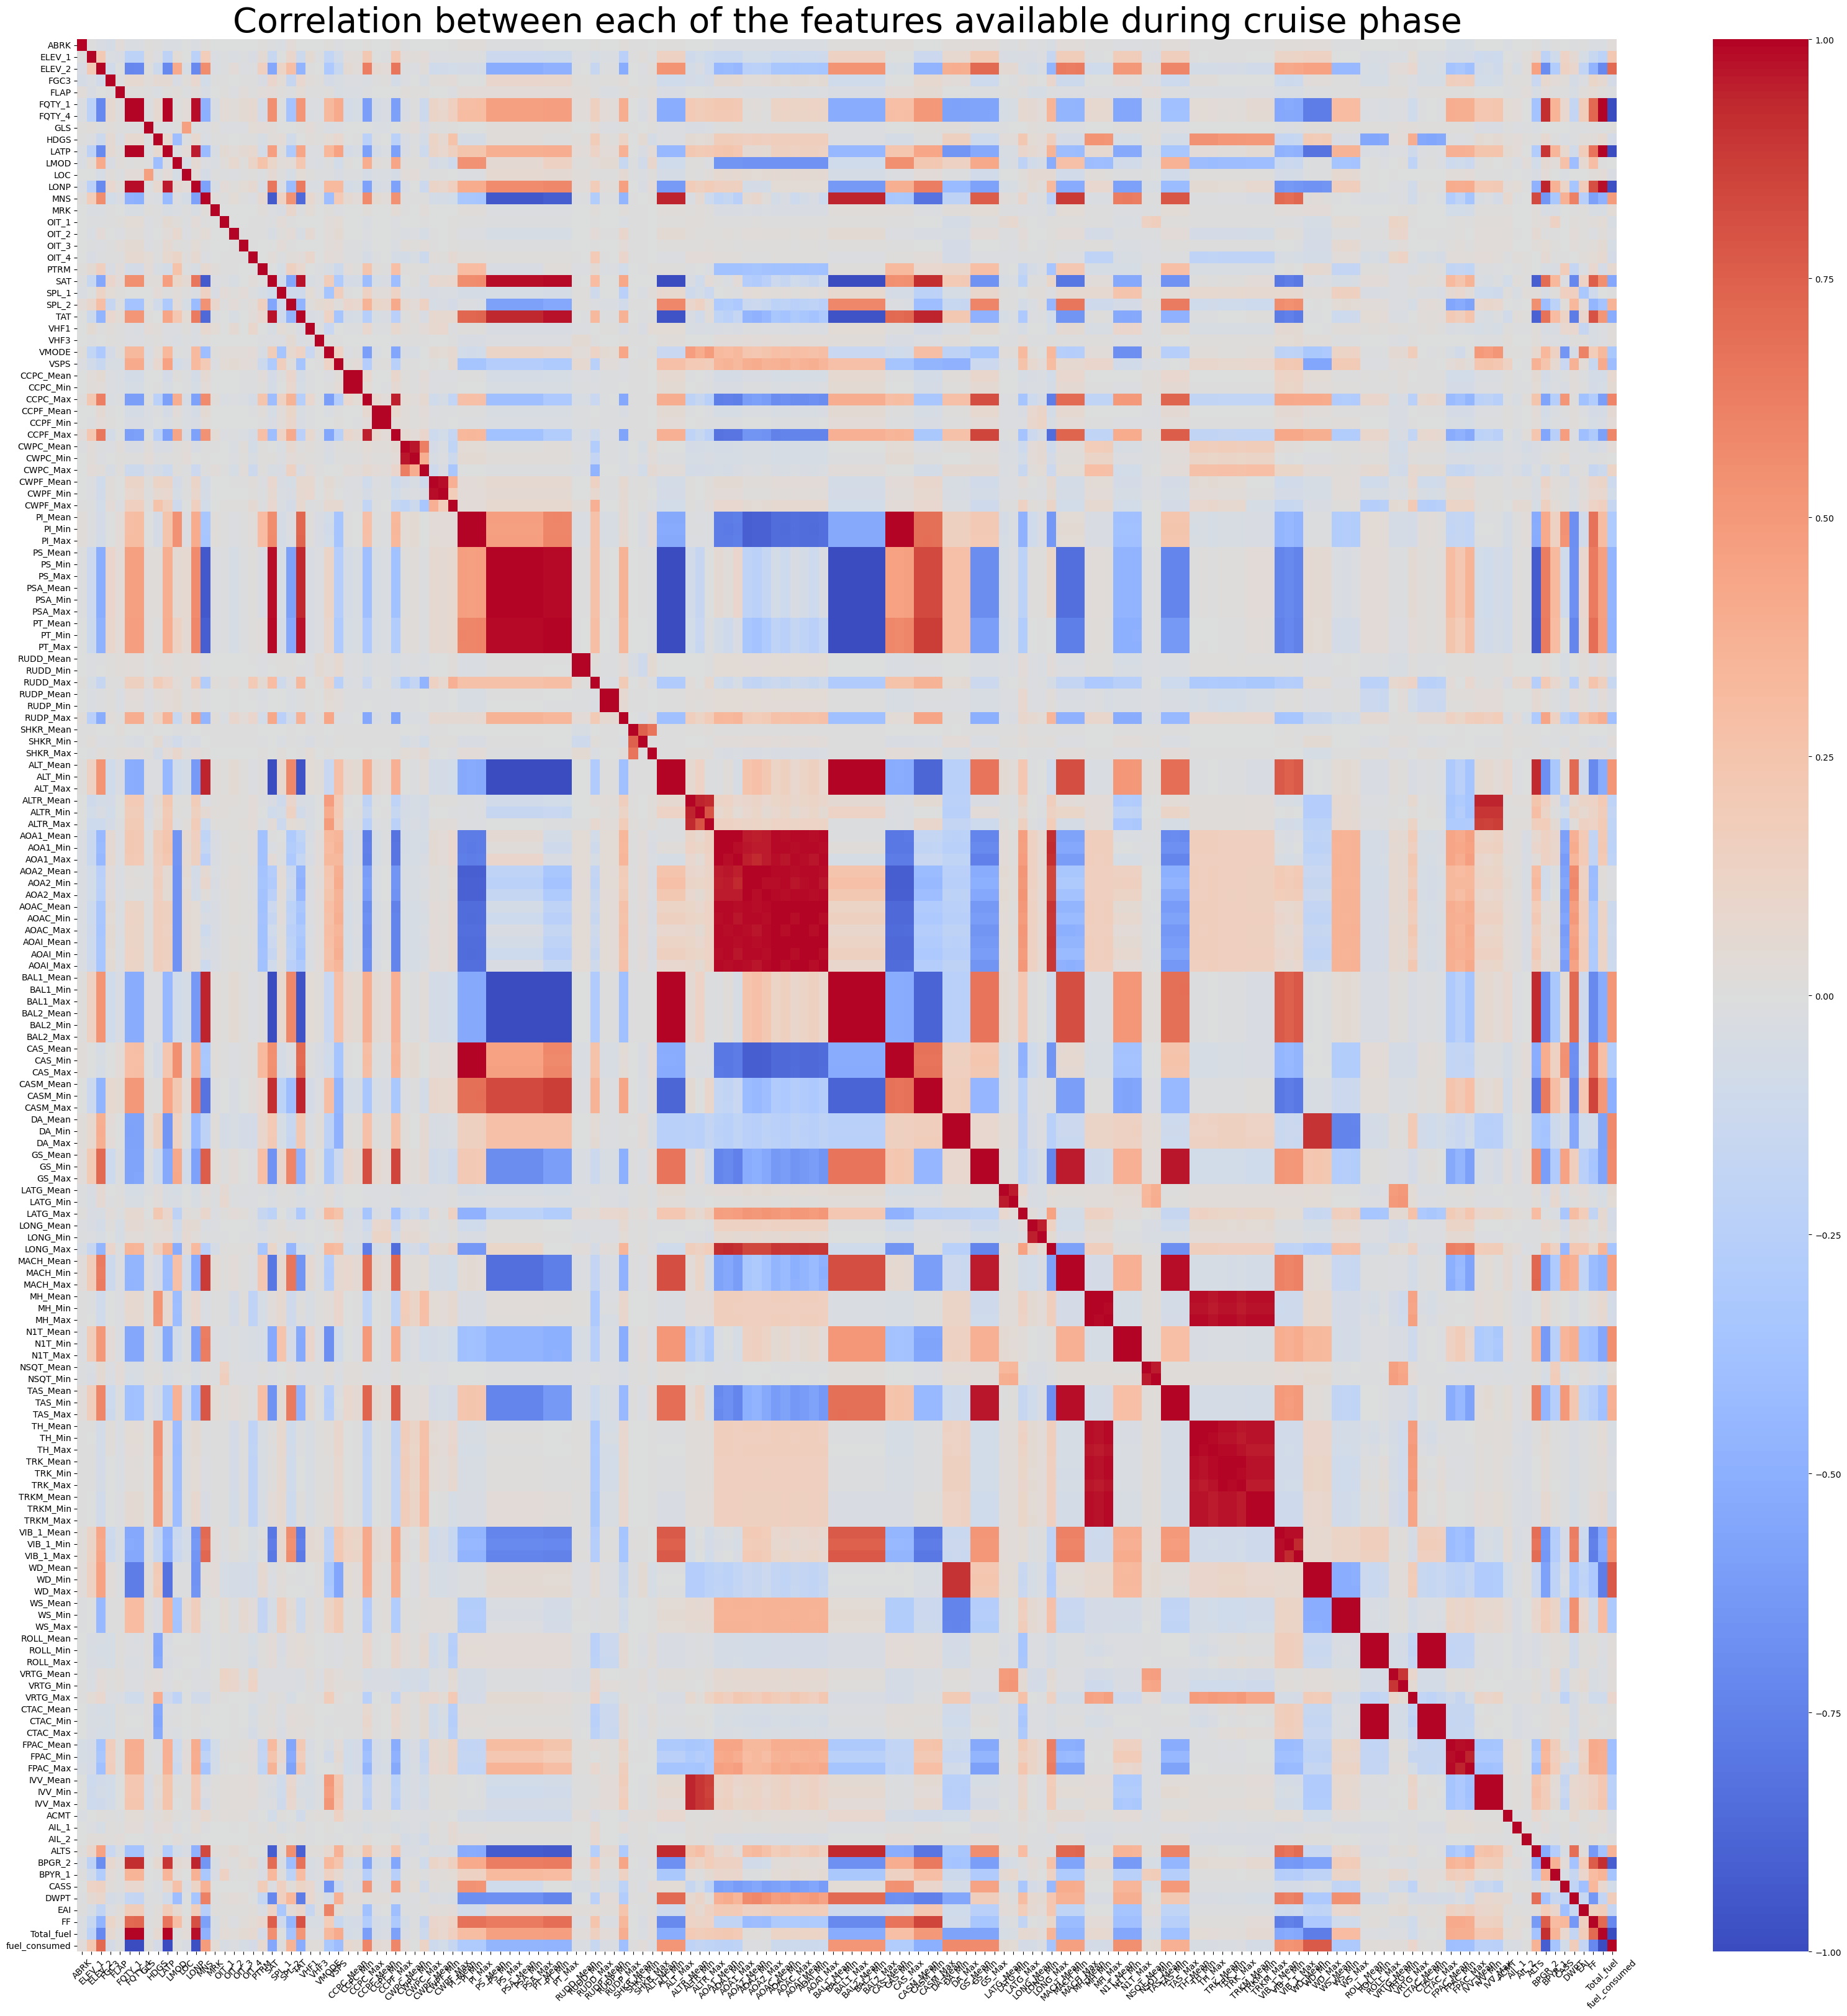

162


(array([-2.48681671e-02, -1.51053891e-01, -4.74160771e-01,  1.06188144e-01,
         4.10779169e-02,  7.16320336e-01,  7.20152486e-01,  1.77393695e-04,
         2.07971574e-02,  6.65430526e-01,  2.92644904e-01,  1.92843700e-02,
         8.07816190e-01, -5.88004835e-01, -4.13519125e-02,  1.68486275e-02,
        -1.92988225e-02,  1.88706929e-02,  4.17780335e-02,  8.47319353e-02,
         7.55207074e-01, -1.02217947e-01, -4.56563990e-01,  7.99363901e-01,
        -4.36184887e-02, -3.93894697e-02,  1.84515445e-01, -1.51888197e-01,
        -7.31572455e-02, -6.29335468e-02, -2.86665601e-01, -6.67994992e-02,
        -5.40547268e-02, -3.11834088e-01, -5.47260855e-02, -9.51971672e-03,
        -1.60685699e-01,  9.96475108e-02,  7.83737030e-02,  1.25647465e-01,
         6.77158253e-01,  6.76529383e-01,  6.77739420e-01,  6.32888613e-01,
         6.32924645e-01,  6.32852548e-01,  6.32907598e-01,  6.32924394e-01,
         6.32890772e-01,  6.88234454e-01,  6.88517340e-01,  6.87950555e-01,
        -1.6

In [397]:
corr_matrix2_cruise = numeric_columns_dataset_cruise.drop(columns=variance0_cruise).corr()
# creates a temporary copy of the data without the specified columns leaving original dataset(here, 
# numeric_columns_dataset) untouched and .corr() function runs immediately on that temporary, cleaned copy
plt.figure(figsize=(40,40))
sns.heatmap(corr_matrix2_cruise, cmap = 'coolwarm')
plt.title("Correlation between each of the features available during cruise phase", fontsize = 40)
plt.xticks(rotation=45)
plt.show()
corr_values_with_FF2 = corr_matrix2_cruise['FF']
print(len(corr_values_with_FF2.values))
corr_values_with_FF2.values, numeric_columns_dataset_cruise.columns

In [398]:
corr_matrix2_cruise.shape

(162, 162)

To see where the NaNs are in the correlation matrix, run below code

In [402]:
nan_rows = corr_matrix2_cruise.isna().any(axis=1)
print(corr_matrix2_cruise.loc[nan_rows, nan_rows])

Empty DataFrame
Columns: []
Index: []


In [404]:
numeric_columns_dataset_cruise['CRSS'].var(), numeric_columns_dataset_cruise['CRSS'].nunique(),  numeric_columns_dataset_cruise['Flight_instance_ID'].var(), numeric_columns_dataset_cruise['Flight_instance_ID'].nunique()

(8.407939896551452e-24, 1, 0.0, 1)

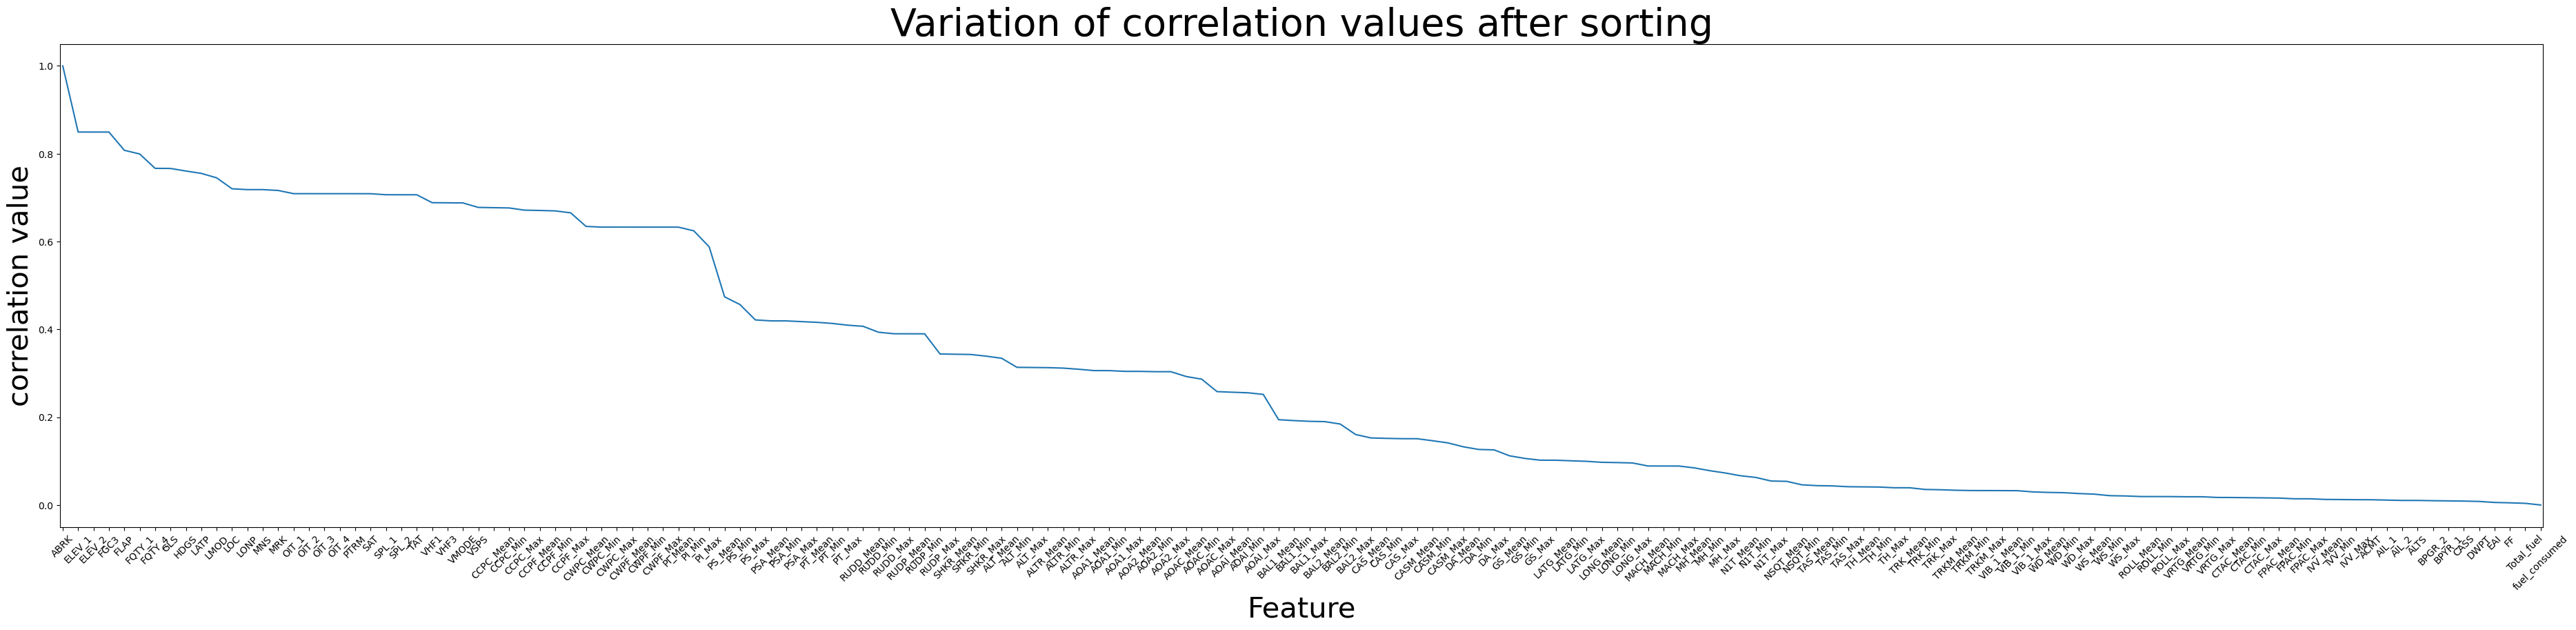

Top 50 correlated features : 
FF               1.000000
CASM_Min         0.849375
CASM_Mean        0.849341
CASM_Max         0.849317
LONP             0.807816
TAT              0.799364
VIB_1_Mean       0.766687
VIB_1_Max        0.766476
BPGR_2           0.760598
SAT              0.755207
VIB_1_Min        0.745084
FQTY_4           0.720152
Total_fuel       0.718287
fuel_consumed    0.718287
FQTY_1           0.716320
BAL2_Max         0.709032
BAL1_Max         0.709018
BAL2_Mean        0.708997
BAL1_Mean        0.708978
BAL2_Min         0.708969
BAL1_Min         0.708940
ALT_Max          0.706610
ALT_Mean         0.706563
ALT_Min          0.706529
PT_Min           0.688517
PT_Mean          0.688234
PT_Max           0.687951
PI_Max           0.677739
PI_Mean          0.677158
PI_Min           0.676529
CAS_Max          0.671519
CAS_Mean         0.670801
CAS_Min          0.669794
LATP             0.665431
DWPT             0.634476
PS_Min           0.632925
PSA_Min          0.632924
PSA_Mean

FF           1.000000
CASM_Min     0.849375
CASM_Mean    0.849341
CASM_Max     0.849317
LONP         0.807816
               ...   
ALTR_Min     0.112192
FGC3         0.106188
SPL_1        0.102218
LONG_Max     0.102123
VRTG_Max     0.100781
Name: FF, Length: 99, dtype: float64

In [406]:
sorted_correlation_values = corr_values_with_FF2.abs().sort_values(ascending = False)
plt.figure(figsize = (40,10))
plt.title("Variation of correlation values after sorting", fontsize = 40)
plt.plot(corr_matrix2_cruise.columns, sorted_correlation_values)
plt.xlabel("Feature", fontsize = 30)
plt.ylabel("correlation value", fontsize = 30)
plt.margins(x=0.001)
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.2)
plt.xticks(rotation=45)
plt.show()

print("Top 50 correlated features : ")
print(sorted_correlation_values.head(50))  
high_correlated = sorted_correlation_values[sorted_correlation_values > 0.1]
print("Features with correlation > 0.1 are")
high_correlated

Coorelation with 'Fuel_consumed'

In [409]:
corr_values_with_FC = corr_matrix2_cruise['fuel_consumed']
print(len(corr_values_with_FC.values))
corr_values_with_FC.values, numeric_columns_dataset_cruise.columns

162


(array([ 0.02972937,  0.2204141 ,  0.71813327, -0.06960579, -0.0151165 ,
        -0.99996383, -0.9999657 ,  0.01354691, -0.06448459, -0.99527725,
        -0.00459447, -0.03506372, -0.98037005,  0.49187808,  0.04396346,
        -0.04618155, -0.01923347, -0.05167466, -0.06911797,  0.0701709 ,
        -0.54929586,  0.00373871,  0.36166642, -0.51902343,  0.02314278,
         0.02231254, -0.32222195, -0.41197657,  0.07087725,  0.04944223,
         0.59594862,  0.05792454,  0.03353512,  0.59293417,  0.03276518,
        -0.00174824,  0.11800839, -0.11303771, -0.08571847, -0.15709486,
        -0.299341  , -0.2984594 , -0.30020227, -0.46380275, -0.46382755,
        -0.46377793, -0.46380728, -0.46382228, -0.46379226, -0.47216623,
        -0.4722644 , -0.47206728, -0.03019892, -0.02840321, -0.15142806,
        -0.03182788, -0.02880147, -0.39803663,  0.00271784,  0.03116132,
        -0.03074053,  0.51586783,  0.515845  ,  0.51589766, -0.20829925,
        -0.17649383, -0.2022019 , -0.21729394, -0.2

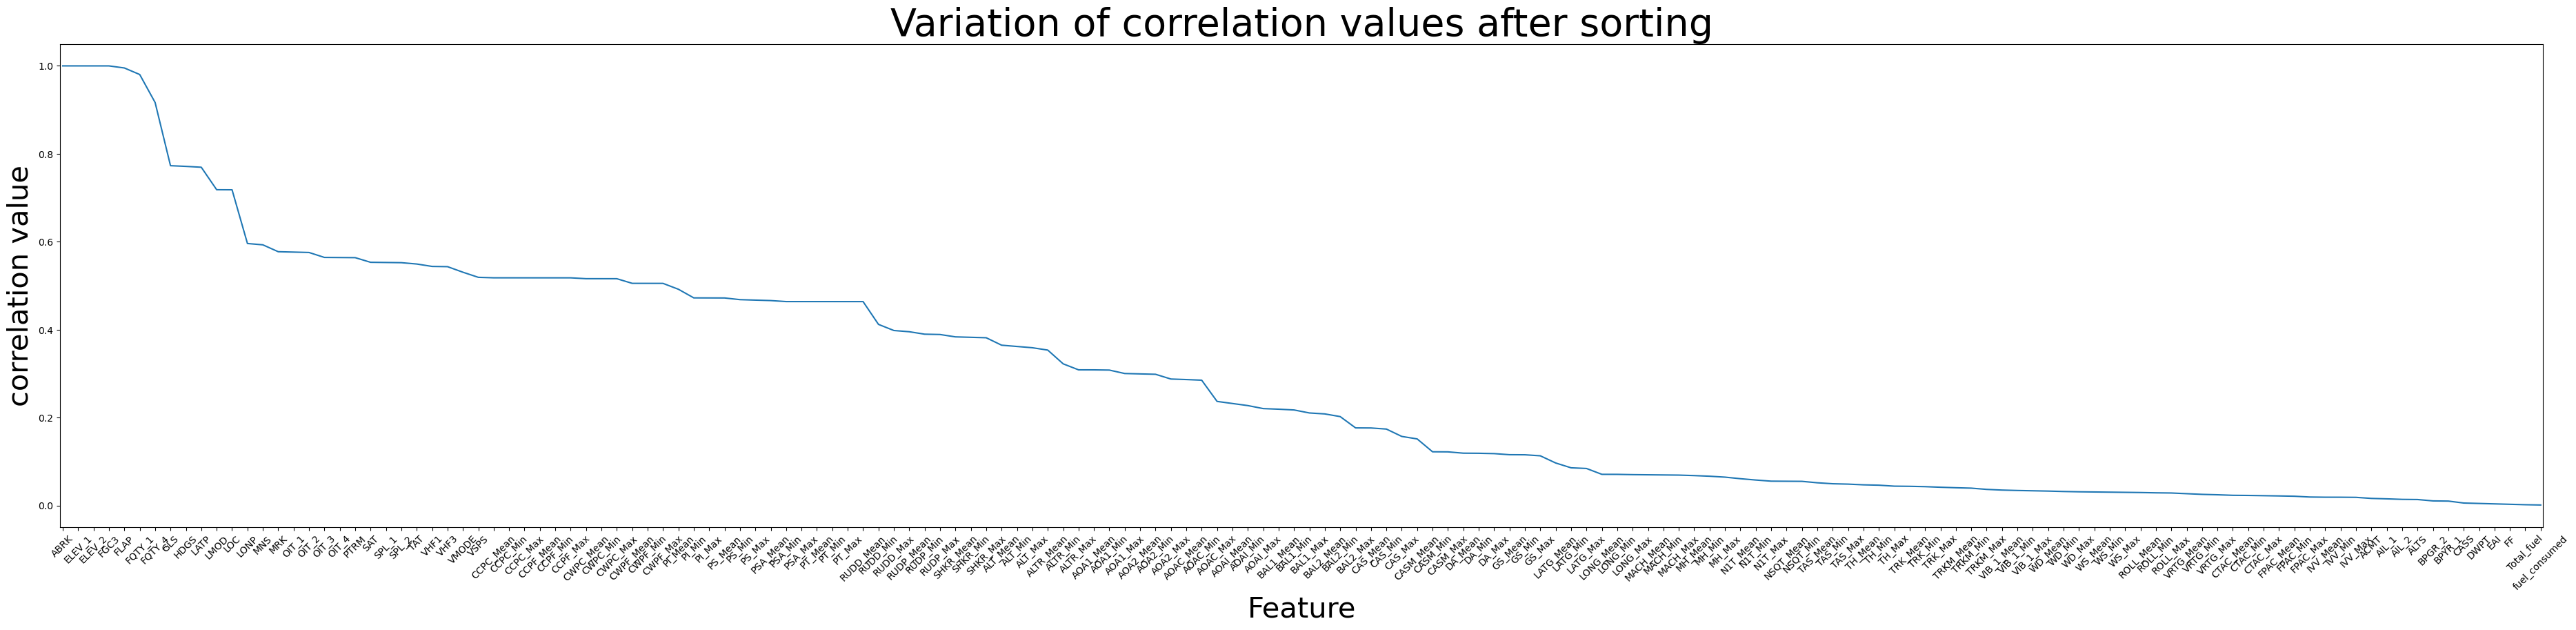

Top 50 correlated features : 
fuel_consumed    1.000000
Total_fuel       1.000000
FQTY_4           0.999966
FQTY_1           0.999964
LATP             0.995277
LONP             0.980370
BPGR_2           0.916725
WD_Min           0.772963
WD_Mean          0.771390
WD_Max           0.769426
FF               0.718287
ELEV_2           0.718133
CCPC_Max         0.595949
CCPF_Max         0.592934
DA_Min           0.577287
DA_Mean          0.576439
DA_Max           0.575520
GS_Min           0.564288
GS_Mean          0.564016
GS_Max           0.563766
N1T_Max          0.553196
N1T_Mean         0.552781
N1T_Min          0.552343
SAT              0.549296
VIB_1_Max        0.543811
VIB_1_Mean       0.543283
VIB_1_Min        0.530623
TAT              0.519023
BAL2_Max         0.517926
BAL1_Max         0.517917
BAL2_Mean        0.517901
BAL1_Mean        0.517888
BAL2_Min         0.517884
BAL1_Min         0.517861
ALT_Max          0.515898
ALT_Mean         0.515868
ALT_Min          0.515845
CASM_Max

fuel_consumed    1.000000
Total_fuel       1.000000
FQTY_4           0.999966
FQTY_1           0.999964
LATP             0.995277
                   ...   
AOAI_Mean        0.118776
CWPC_Max         0.118008
AOAC_Max         0.115524
AOAI_Max         0.115344
CWPF_Mean        0.113038
Name: fuel_consumed, Length: 97, dtype: float64

In [411]:
sorted_correlation_values = corr_values_with_FC.abs().sort_values(ascending = False)
plt.figure(figsize = (40,10))
plt.title("Variation of correlation values after sorting", fontsize = 40)
plt.plot(corr_matrix2_cruise.columns, sorted_correlation_values)
plt.xlabel("Feature", fontsize = 30)
plt.ylabel("correlation value", fontsize = 30)
plt.margins(x=0.001)
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.2)
plt.xticks(rotation=45)
plt.show()

print("Top 50 correlated features : ")
print(sorted_correlation_values.head(50))  
high_correlated = sorted_correlation_values[sorted_correlation_values > 0.1]
print("Features with correlation > 0.1 are")
high_correlated

In [415]:
dummy_cruise = numeric_columns_dataset_cruise.drop(columns=variance0_cruise).copy()


# dummy_cruise will work only on columns which don't have zero variance
print(list(dummy_cruise.columns))
print(len(dummy_cruise.columns))
print(len(random_df_cruise.columns))
print(dummy_cruise.shape)
dummy_cruise['fuel_consumed'], dummy_cruise['Total_fuel']

['ABRK', 'ELEV_1', 'ELEV_2', 'FGC3', 'FLAP', 'FQTY_1', 'FQTY_4', 'GLS', 'HDGS', 'LATP', 'LMOD', 'LOC', 'LONP', 'MNS', 'MRK', 'OIT_1', 'OIT_2', 'OIT_3', 'OIT_4', 'PTRM', 'SAT', 'SPL_1', 'SPL_2', 'TAT', 'VHF1', 'VHF3', 'VMODE', 'VSPS', 'CCPC_Mean', 'CCPC_Min', 'CCPC_Max', 'CCPF_Mean', 'CCPF_Min', 'CCPF_Max', 'CWPC_Mean', 'CWPC_Min', 'CWPC_Max', 'CWPF_Mean', 'CWPF_Min', 'CWPF_Max', 'PI_Mean', 'PI_Min', 'PI_Max', 'PS_Mean', 'PS_Min', 'PS_Max', 'PSA_Mean', 'PSA_Min', 'PSA_Max', 'PT_Mean', 'PT_Min', 'PT_Max', 'RUDD_Mean', 'RUDD_Min', 'RUDD_Max', 'RUDP_Mean', 'RUDP_Min', 'RUDP_Max', 'SHKR_Mean', 'SHKR_Min', 'SHKR_Max', 'ALT_Mean', 'ALT_Min', 'ALT_Max', 'ALTR_Mean', 'ALTR_Min', 'ALTR_Max', 'AOA1_Mean', 'AOA1_Min', 'AOA1_Max', 'AOA2_Mean', 'AOA2_Min', 'AOA2_Max', 'AOAC_Mean', 'AOAC_Min', 'AOAC_Max', 'AOAI_Mean', 'AOAI_Min', 'AOAI_Max', 'BAL1_Mean', 'BAL1_Min', 'BAL1_Max', 'BAL2_Mean', 'BAL2_Min', 'BAL2_Max', 'CAS_Mean', 'CAS_Min', 'CAS_Max', 'CASM_Mean', 'CASM_Min', 'CASM_Max', 'DA_Mean', 'DA_M

(1826       0
 1827       0
 1828       0
 1829       0
 1830       0
         ... 
 5819    5440
 5820    5408
 5821    5432
 5822    5408
 5823    5392
 Name: fuel_consumed, Length: 2300, dtype: int64,
 1826    12688
 1827    12688
 1828    12688
 1829    12688
 1830    12688
         ...  
 5819     7248
 5820     7280
 5821     7256
 5822     7280
 5823     7296
 Name: Total_fuel, Length: 2300, dtype: int64)

In [417]:
          ### Backward Elimination (Feature Selection) using a statistical approach ###
# trying to weed out the "noise" in dataset by checking which features actually have a statistically significant relationship with target variable
import pandas as pd
import statsmodels.api as sm

X = dummy_cruise.drop(columns=['Total_fuel','FQTY_1','FQTY_4','FF', 'fuel_consumed'])
y = dummy_cruise['fuel_consumed']
print(list(X.columns))

# Statsmodels requires to explicitly add a constant (intercept) term
X_with_constant = sm.add_constant(X)
# OLS Model is fitted
model = sm.OLS(y, X_with_constant).fit()
print(model.pvalues) 
# Extracting all p-values
p_values = model.pvalues.drop('const')

# p <= 0.05: The feature is statistically significant (keep it).
#  p > 0.05: The feature is not statistically significant (drop it).
insignificant_columns = p_values[p_values > 0.05].index.tolist()
significant_columns = p_values[p_values <= 0.05].index.tolist()
print("insignificant_columns.len", len(insignificant_columns))
print("significant_columns.len", len(significant_columns))
print("Columns to drop (p > 0.05):", insignificant_columns)
print("Columns to keep (p <= 0.05):", significant_columns)

# 6. Filter to keep only the significant features
X_cleaned = X[significant_columns]
X_cleaned
X_cleaned2 = X_cleaned.copy()
## due to very high correlation; if they are critical for prediction, then must be included irrespective of corr like area for house price
X_cleaned = X_cleaned.drop(columns=['LATP','LONP','BPGR_2'])  
# Timestamp is meant to be dropped to avoid temporaL data leakage but it's already excluded when 'numeric_columns_dataset_cruise'
# was made. TimeSeriesSplit is used instead of KFold


['ABRK', 'ELEV_1', 'ELEV_2', 'FGC3', 'FLAP', 'GLS', 'HDGS', 'LATP', 'LMOD', 'LOC', 'LONP', 'MNS', 'MRK', 'OIT_1', 'OIT_2', 'OIT_3', 'OIT_4', 'PTRM', 'SAT', 'SPL_1', 'SPL_2', 'TAT', 'VHF1', 'VHF3', 'VMODE', 'VSPS', 'CCPC_Mean', 'CCPC_Min', 'CCPC_Max', 'CCPF_Mean', 'CCPF_Min', 'CCPF_Max', 'CWPC_Mean', 'CWPC_Min', 'CWPC_Max', 'CWPF_Mean', 'CWPF_Min', 'CWPF_Max', 'PI_Mean', 'PI_Min', 'PI_Max', 'PS_Mean', 'PS_Min', 'PS_Max', 'PSA_Mean', 'PSA_Min', 'PSA_Max', 'PT_Mean', 'PT_Min', 'PT_Max', 'RUDD_Mean', 'RUDD_Min', 'RUDD_Max', 'RUDP_Mean', 'RUDP_Min', 'RUDP_Max', 'SHKR_Mean', 'SHKR_Min', 'SHKR_Max', 'ALT_Mean', 'ALT_Min', 'ALT_Max', 'ALTR_Mean', 'ALTR_Min', 'ALTR_Max', 'AOA1_Mean', 'AOA1_Min', 'AOA1_Max', 'AOA2_Mean', 'AOA2_Min', 'AOA2_Max', 'AOAC_Mean', 'AOAC_Min', 'AOAC_Max', 'AOAI_Mean', 'AOAI_Min', 'AOAI_Max', 'BAL1_Mean', 'BAL1_Min', 'BAL1_Max', 'BAL2_Mean', 'BAL2_Min', 'BAL2_Max', 'CAS_Mean', 'CAS_Min', 'CAS_Max', 'CASM_Mean', 'CASM_Min', 'CASM_Max', 'DA_Mean', 'DA_Min', 'DA_Max', 'GS_M

In [419]:
correlations = X_cleaned.corrwith(y).abs()
print(correlations.sort_values(ascending=False).head(5))

WD_Mean     0.771390
WD_Max      0.769426
ELEV_2      0.718133
N1T_Max     0.553196
N1T_Mean    0.552781
dtype: float64


In [421]:
print(dummy_cruise.shape)  

(2300, 162)


In [425]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold,cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [427]:
from sklearn.pipeline import make_pipeline
lin_reg = LinearRegression()
# Create a 'KFold' object that shuffles
kf = KFold(n_splits=9, shuffle=True, random_state=42)
# This way forces scaling to happen strictly inside each fold loop
pipeline = make_pipeline(StandardScaler(), lin_reg)
scoring_metrics = {
    'mse': 'neg_mean_squared_error',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}
results = cross_validate(pipeline, X_cleaned, y, cv=kf, scoring=scoring_metrics)

print(f"Mean RMSE:{(-results['test_rmse']).mean()}, variation Ratio: {(-results['test_rmse']).std()/(-results['test_rmse']).mean()}")
print(f"Mean MAE:{(-results['test_mae']).mean()}, variation Ratio: {(-results['test_mae']).std()/(-results['test_mae']).mean()}")
print(f"Mean R2:{(results['test_r2']).mean()}, variation Ratio: {(results['test_r2']).std()/(results['test_r2']).mean()}")


Mean RMSE:139.52760029277863, variation Ratio: 0.07314753767746011
Mean MAE:95.18737900967638, variation Ratio: 0.035029709574658875
Mean R2:0.9905508678394137, variation Ratio: 0.001592344306136225


In [428]:


lin_reg2 = LinearRegression()
kf = KFold(n_splits=9, shuffle=True, random_state=42)
# shuffling could be useful as data might be sorted in some order, thus few CV iterations perfoming very good and some so worst that CV scores variation is high
mse = cross_val_score(lin_reg2, X_cleaned, y, scoring='neg_mean_squared_error', cv=kf)
# 'cross_val_score' trains and tests on single metric entered
mse_scores = -mse
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)

# Ratio of variation
variation_ratio = std_mse / mean_mse
print('variation_ratio',variation_ratio)
if variation_ratio < 0.10:
    print("Stable: Variation is less than 10%.")
elif variation_ratio < 0.20:
    print("Acceptable: Moderate variation.")
else:
    print("Unstable: High variation; the model is inconsistent.")

from sklearn.model_selection import cross_validate

# multiple metrics can be tracked
scoring_metrics = {
    'mse': 'neg_mean_squared_error',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# Run cross-validation
results = cross_validate(lin_reg2, X_cleaned, y, cv=kf, scoring=scoring_metrics)
# 'cross_validate' trains the model exactly once per fold. It then calculates all requested metrics (MSE, MAE, R2)
# simultaneously on that same trained fold. Additionally, it returns dictionary with fit_time, score_time & train_score.

print(f"Mean RMSE:{(-results['test_rmse']).mean()}, variation Ratio: {(-results['test_rmse']).std()/(-results['test_rmse']).mean()}")
print(f"Mean MAE:{(-results['test_mae']).mean()}, variation Ratio: {(-results['test_mae']).std()/(-results['test_mae']).mean()}")
print(f"Mean R2:{(results['test_r2']).mean()}, variation Ratio: {(results['test_r2']).std()/(results['test_r2']).mean()}")



X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.33, random_state=42)

lin_reg2.fit(X_train, y_train)
print('lin_reg2.score Train performance',lin_reg2.score(X_train, y_train))
# 3. Check performance on new/test data
print(f"lin_reg2_Test Performance: {lin_reg2.score(X_test, y_test)}")



variation_ratio 0.1433740912377967
Acceptable: Moderate variation.
Mean RMSE:139.52760029328684, variation Ratio: 0.07314753767755615
Mean MAE:95.18737900933257, variation Ratio: 0.03502970958318457
Mean R2:0.9905508678393345, variation Ratio: 0.0015923443062009289
lin_reg2.score Train performance 0.9912166371317175
lin_reg2_Test Performance: 0.9916116814336821


R2 of 0.999 says  model explains almost 100% of the variance in the data. It is a near-perfect fit.
R2 variation ratio of 0.06 shows model is stable

Variation ratio of RMSE & MAE being > 1 is quite normal as these two are unbounded real numbers unlike R2 which is within 0-1, among few other reasons. In real-world data with outliers, a single bad fold artificially inflates the standard deviation of errors while the mean stays relatively low, pushing the ratio (std / mean) past 1.0. **A ratio near or above 1 is acceptable only if R2 is still high. It simply signals that your data contains unavoidable outliers, but the model is doing its best**

For MAE and RMSE, compare mean values with raw data for example MAE of Rs.50 in House pricing is minimal but MAE of 50 years in predicting person's age is bad. . If mean MAE is less than 10% of target variable's overall standard deviation, model's prediction errors are very small. For MSE there are other ways to infer what it is saying about model.

An individual feature can have a low correlation with y but still have a massive coefficient because of a phenomenon called Multicollinearity or Collinearity

Polynomial regression cannot be used here as it is used when model is performing poorly because curved relationships are not captured by linear regression i.e. R2 is low but still positive like 0.20.
Here, the problem is that linear model is too perfect (R2 of 0.99) hence if straight line can hit a 0.99 score, thrn adding polynomial curves will make model more complex and overfit. Also due to large no. of features even trying combination to create 2nd degree polynomial will burst into numerous features (curse of dimensionality)

In [436]:
lin_reg3 = LinearRegression()
lin_reg3.fit(X_cleaned, y)

import pandas as pd
coef_df = pd.DataFrame({'Feature': X_cleaned.columns, 'Coefficient': lin_reg3.coef_})
#print(coef_df.sort_values(by='Coefficient', key=abs, ascending=False).head(5))
# Shows the columns sorted by the absolute size of their impact
print(coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index))

      Feature   Coefficient
28   FPAC_Max -27457.838074
18  TRKM_Mean   9657.053761
27   FPAC_Min   9236.998492
15   MACH_Min   8293.487968
19   TRKM_Min  -5086.597866
20   TRKM_Max  -4570.644438
25   VRTG_Max   2447.024420
26   CTAC_Min   1844.853389
9   AOA1_Mean   -460.628660
7       VMODE    252.683671
30       CASS   -226.387487
16   N1T_Mean    123.225129
17    N1T_Max   -118.493872
4         MNS    102.394095
14  LONG_Mean     85.266187
12   CAS_Mean    -67.884590
21    WD_Mean     30.980193
13    CAS_Min     26.807120
24   ROLL_Max    -24.552351
23     WS_Max    -21.472037
22     WD_Max    -16.507063
32        EAI     -9.812256
5       SPL_1     -7.600850
6       SPL_2      6.769966
2        FLAP      3.597601
1      ELEV_2      2.600040
3        HDGS     -2.362074
11   BAL2_Min     -1.598981
8        VSPS     -0.812978
0        ABRK      0.718708
10   BAL1_Min      0.460240
29       ALTS     -0.073298
31       DWPT     -0.001206


In [438]:
# due to high coefficient than others, trying by dropping that feature
X_cleaned = X_cleaned.drop(columns=['FPAC_Max'])  


When using a standard KFold(shuffle=True) on time-based data, it randomly scatters rows across your folds. This means model is allowed to look at data from tomorrow (in the training fold) to predict what happened yesterday (in the validation fold).

so there's need to stop using KFold. Instead, can use scikit-learn's TimeSeriesSplit. This method acts like a rolling window: it only ever trains on past data and validates on future data, completely blocking time travel.

TimeSeriesSplit does not look at the column names; it only looks at the index of rows. It strictly splits data by taking the top rows as training and the bottom rows as testing

In [441]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
lin_reg4 = LinearRegression()
# Replacing KFold with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=9)

# Running cross-validation using the temporal splits
results = cross_validate(lin_reg4, X_cleaned, y, cv=tscv, scoring=scoring_metrics)

print(f"Realistic Mean R2: {results['test_r2'].mean()}")
print(f"Mean RMSE:{(-results['test_rmse']).mean()}, variation Ratio: {(-results['test_rmse']).std()/(-results['test_rmse']).mean()}")
print(f"Mean MAE:{(-results['test_mae']).mean()}, variation Ratio: {(-results['test_mae']).std()/(-results['test_mae']).mean()}")
print(f"Mean R2:{(results['test_r2']).mean()}, variation Ratio: {(results['test_r2']).std()/(results['test_r2']).mean()}")

Realistic Mean R2: -59.56634090198962
Mean RMSE:935.8935089200199, variation Ratio: 1.2246954828443697
Mean MAE:635.6213295297904, variation Ratio: 1.2004108778725493
Mean R2:-59.56634090198962, variation Ratio: -1.7379120893361917


Even if model does not explicitly see a date or time column because their is no column explicitly indicating date or time but if the rows are naturally structured as "time passed by" (sequential over time), the data is a time series and  **row order is an implicit temporal feature**. Thus TimeSeriesSplit is useful here.

Also Lasso can be used here as there are many highly correlated features which take large coefficients (even though they are dropped, other features correlated to them then get assigned large coefficients), Lasso will keep only 1 of all the correlated independent features and assign others' coefficient to 0.

In [446]:
### this is Lasso model with KFold 

from sklearn.linear_model import LassoCV

lasso_kf = LassoCV(cv=kf, random_state=42)
lasso_kf.fit(X_cleaned2, y)

print(f"Shuffled Lasso R2: {lasso_kf.score(X_cleaned2, y):.4f}") # why cv score not checked

# Check what Lasso kept
coef_df_kf = pd.DataFrame({'Feature': X_cleaned2.columns, 'Coef': lasso_kf.coef_})
print("\nFeatures Shuffled Lasso Kept:")
print(coef_df_kf[coef_df_kf['Coef'] != 0].sort_values(by='Coef', key=abs, ascending=False))

## this is used to get mean R2 of CV
cv_results = cross_validate(lasso_kf, X_cleaned2, y, cv=tscv, scoring='r2')
print("--- True Time-Series Test Scores per Fold ---")
print(cv_results['test_score'])
print(f"\nHonest Out-of-Sample Mean R2: {cv_results['test_score'].mean():.4f}")

Shuffled Lasso R2: 0.6362

Features Shuffled Lasso Kept:
     Feature      Coef
10      VSPS -1.319454
12  BAL1_Min  0.446328
31      ALTS -0.120911
34      DWPT -0.002741
13  BAL2_Min  0.000509
--- True Time-Series Test Scores per Fold ---
[ -32.63500817  -11.57502327  -19.53010028  -36.76094796  -56.32066938
  -46.44490312  -30.25458258  -29.13564761 -476.46222946]

Honest Out-of-Sample Mean R2: -82.1243


**Lasso fixed multicollinearity and feature leakage**
By dropping from 0.99 down to 0.6362, Lasso successfully did what manual dropping couldn't do. It zeroed out all those redundant, high-coefficient features that were mathematically breaking standard linear regression.

An R2 of 0.63 is realistic value and good starting point.

First 5 predictions: [2140.31475552 2140.32441368 2140.94629233 2140.95584528 2140.76142993
 2140.77119329 2140.78085144 2140.3824678  2141.00424125 2140.86788002
 2140.46939117 2140.46928597 2140.48849708 2140.08056048 2140.09987679
 2139.89569808 2139.71094089 2139.72059904 2139.3221102  2138.77749677
 2138.58308142 2138.38877128 2138.19435593 2138.40798238 2138.82568233]


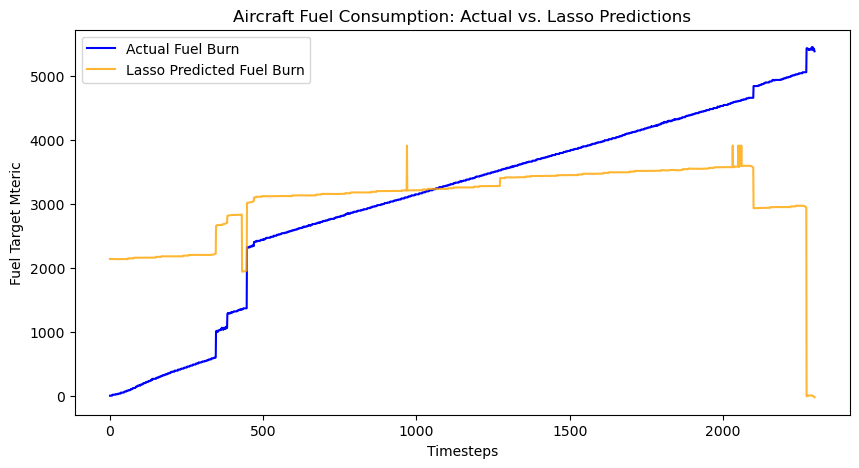

In [448]:
import matplotlib.pyplot as plt
import seaborn as sns

# predictions on data
predictions_kf = lasso_ts.predict(X_cleaned2)
print("First 5 predictions:", predictions_kf[:25])
plt.figure(figsize=(10,5))
sns.lineplot(data=y.values, label='Actual Fuel Burn', color='Blue')
sns.lineplot(data=predictions_kf, label='Lasso Predicted Fuel Burn', color='Orange', alpha=0.8)
plt.title("Aircraft Fuel Consumption: Actual vs. Lasso Predictions")
plt.xlabel('Timesteps')
plt.ylabel('Fuel Target Mteric')
plt.legend()
#plt.savefig('actual_vs_predicted_fuel.png')
plt.show()

In [449]:
## this is exact same Lasso model as above, just with tscv instead of KFold

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=9)
lasso_ts = LassoCV(cv=tscv, random_state=42)
lasso_ts.fit(X_cleaned2, y)

print(f"Time Series Lasso R2: {lasso_ts.score(X_cleaned2, y):.4f}")

## this is used to get mean R2 of CV
cv_results = cross_validate(lasso_ts, X_cleaned2, y, cv=tscv, scoring='r2')
print("--- True Time-Series Test Scores per Fold ---")
print(cv_results['test_score'])
print(f"\nHonest Out-of-Sample Mean R2: {cv_results['test_score'].mean():.4f}")

Time Series Lasso R2: 0.2998
--- True Time-Series Test Scores per Fold ---
[ -32.61334055 -394.31581026  -55.22066901  -94.76734832 -224.99590337
  -46.44490312 -452.60308472 -583.1658384  -476.46222946]

Honest Out-of-Sample Mean R2: -262.2877


Because rows represent "time passing by," the data patterns change over time. TimeSeriesSplit TSCV enforced a strict chronological rule: train only on the past, test only on the future. This is what completely blocked the temporal (time-travel) leakage.
But Lasso did prevent the model from exploding into erratic predictions like -44.25 earlier
 

In [451]:
# predictions on data
predictions_tscv = lasso_ts.predict(X_cleaned2)
print("First 5 predictions:", predictions_tscv[:25])

First 5 predictions: [2140.31475552 2140.32441368 2140.94629233 2140.95584528 2140.76142993
 2140.77119329 2140.78085144 2140.3824678  2141.00424125 2140.86788002
 2140.46939117 2140.46928597 2140.48849708 2140.08056048 2140.09987679
 2139.89569808 2139.71094089 2139.72059904 2139.3221102  2138.77749677
 2138.58308142 2138.38877128 2138.19435593 2138.40798238 2138.82568233]


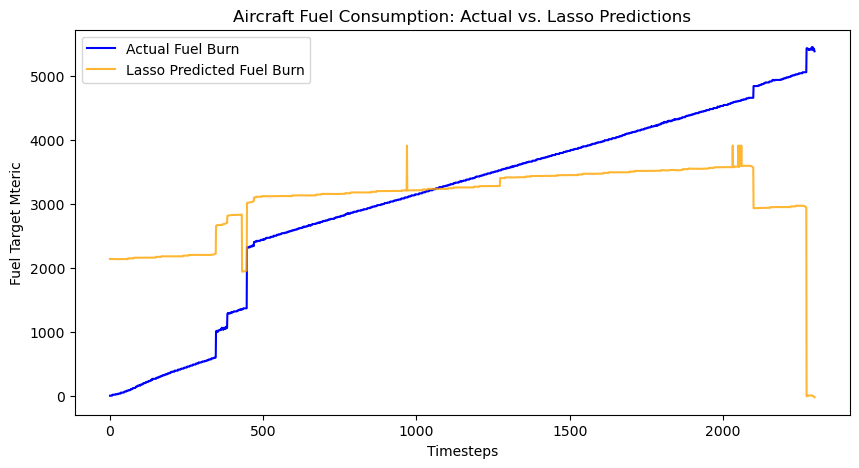

In [452]:

plt.figure(figsize=(10,5))
sns.lineplot(data=y.values, label='Actual Fuel Burn', color='Blue')
sns.lineplot(data=predictions_tscv, label='Lasso Predicted Fuel Burn', color='Orange', alpha=0.8)
plt.title("Aircraft Fuel Consumption: Actual vs. Lasso Predictions")
plt.xlabel('Timesteps')
plt.ylabel('Fuel Target Mteric')
plt.legend()
#plt.savefig('actual_vs_predicted_fuel.png')
plt.show()

Creating Lag features using y, which tells model what happened in the immediate "past" row

In [455]:
X_lagged = X_cleaned.copy()

X_lagged['lag_1'] = y.shift(1)
X_lagged['lag_2'] = y.shift(2)
X_lagged['lag_3'] = y.shift(3)

X_lagged = X_lagged.dropna()
y_lagged = y.loc[X_lagged.index] 
tscv = TimeSeriesSplit(n_splits=5)
lasso_ts_lagged = LassoCV(cv=tscv, random_state=42)
lasso_ts_lagged.fit(X_lagged, y_lagged)

print(f"New Time Series Lasso R2 (With Lags): {lasso_ts_lagged.score(X_lagged, y_lagged):.4f}")

cv_results = cross_validate(lasso_ts_lagged, X_lagged, y_lagged, cv=tscv, scoring='r2')

print("--- True Time-Series Test Scores per Fold ---")
print(cv_results['test_score'])
print(f"\nHonest Out-of-Sample Mean R2: {cv_results['test_score'].mean():.4f}")

New Time Series Lasso R2 (With Lags): 0.9996
--- True Time-Series Test Scores per Fold ---
[  -2.02663832  -37.31772573 -118.64516166 -138.88606016 -106.21367447]

Honest Out-of-Sample Mean R2: -80.6179


An R2 of 0.9996 means we have run into another classic time-series trap: The Naive Forecast Illusion (also known as the Random Walk trap).

negative cv score -80.61 confirms model R2 of 0.9996 is Naive Forecast Trap. When training on past data, the Lasso model relied entirely on lag_1 (just copying the previous row's value). However, the moment it was forced to predict a completely new chunk of the future (out-of-sample folds), that strategy failed and negative R2 flowed.

Using Differencing method here. which asks model 'by how much the value go up or down' i.e. difference
instead of asking 'what will be the exact value tomorrow'

In [459]:
y_diff = y.diff().dropna()

X_diff = X_cleaned2.diff().dropna()

common_index = X_diff.index.intersection(y_diff.index)
X_stationary = X_diff.loc[common_index]
y_stationary = y_diff.loc[common_index]

X_stationary['lag_1_change'] = y_stationary.shift(1)
X_stationary['lag_2_change'] = y_stationary.shift(2)
X_stationary = X_stationary.dropna()
y_stationary = y_stationary.loc[X_stationary.index]

tscv = TimeSeriesSplit(n_splits=9)
lasso_stationary = LassoCV(cv=tscv, random_state=42)
cv_results = cross_validate(lasso_stationary, X_stationary, y_stationary, cv=tscv, scoring='r2')

print("--- New Stationary Test Scores per Fold ---")
print(cv_results['test_score'])
print(f"\nNew Honest Out-of-Sample Mean R2: {cv_results['test_score'].mean():.4f}")

--- New Stationary Test Scores per Fold ---
[-9.12334927e-02  5.46969395e-01 -2.67677242e-02 -7.01056806e-01
 -1.89005345e-02  1.07702586e-02 -2.18763247e-02 -1.84180589e-01
 -6.17233495e+01]

New Honest Out-of-Sample Mean R2: -6.9122


reason for overall average of -6.91 is entirely due to that last single fold crashing to -61.72, i.e. data patterns changed completely in that final stretch of time (this can actually be seen in fuel_consumed vs Timestamp plot that last part of blue line seems not to be increasing as it was doing for previous ones).

Let's check this

In [462]:
tscv = TimeSeriesSplit(n_splits=9)
splits = list(tscv.split(X_stationary))
train_idx, test_idx = splits[-1]  # Get the last fold indices
X_train, X_test = X_stationary.iloc[train_idx], X_stationary.iloc[test_idx]
y_train, y_test = y_stationary.iloc[train_idx], y_stationary.iloc[test_idx]
lasso_stationary.fit(X_train, y_train)
predictions = lasso_stationary.predict(X_test)

analysis_df = pd.DataFrame({
    'Actual_Change': y_test,
    'Predicted_Change': predictions,
    'Absolute_Error': np.abs(y_test - predictions)
}, index=y_test.index)

print("--- Top 10 Most Out-of-Trend Rows causing the Crash ---")
print(analysis_df.sort_values(by='Absolute_Error', ascending=False).head(10))

--- Top 10 Most Out-of-Trend Rows causing the Crash ---
      Actual_Change  Predicted_Change  Absolute_Error
5797          376.0      -2868.945118     3244.945118
5146          184.0       -747.687060      931.687060
5815          -40.0          0.727177       40.727177
5814           32.0          2.079635       29.920365
5820          -32.0         -2.750767       29.249233
5821           24.0         -1.977740       25.977740
5816           24.0         -1.205100       25.205100
5822          -24.0         -1.784531       22.215469
5818          -24.0         -1.784725       22.215275
5817           16.0          1.114755       14.885245


Two extreme outliers are causing majority of crash, Row index 5797 & 5146


In [466]:
rows_to_drop = [5146, 5797]  # dropping those two rows
X_clean_time = X_stationary.drop(index=rows_to_drop, errors='ignore')
y_clean_time = y_stationary.drop(index=rows_to_drop, errors='ignore')
from sklearn.model_selection import cross_validate
tscv = TimeSeriesSplit(n_splits=9)

cv_results_final = cross_validate(lasso_stationary, X_clean_time, y_clean_time, cv=tscv, scoring='r2')

print("--- Final Cleaned Test Scores per Fold ---")
print(cv_results_final['test_score'])
print(f"\nCleaned Honest Mean R2: {cv_results_final['test_score'].mean():.4f}")

lasso_stationary.fit(X_clean_time, y_clean_time)
train_r2 = lasso_stationary.score(X_clean_time, y_clean_time)

print("--- Final Model Performance Comparison ---")
print(f"Training Data R2 Score:    {train_r2:.4f}")
print(f"Cross-Validated Mean R2: {cv_results_final['test_score'].mean():.4f}")

--- Final Cleaned Test Scores per Fold ---
[-0.09221857  0.53600304 -0.02946169 -0.69726936 -0.02052643  0.01140634
 -0.02234554 -0.18449944  0.0400883 ]

Cleaned Honest Mean R2: -0.0510
--- Final Model Performance Comparison ---
Training Data R2 Score:    0.9488
Cross-Validated Mean R2: -0.0510


An R² score hovering right around 0.0 (or slightly negative) means that model's predictions on unseen future data are performing exactly the same as a flat baseline line that just guesses the historical average value of your target.

Because we are predicting step-by-step changes (differenced data), hitting an R² near 0.0 is the textbook behavior for a dataset that behaves like a Random Walk like Stock market returns, means that a straight, linear relationship using past changes cannot accurately forecast future changes. **The Lasso model is almost maxed out here.**

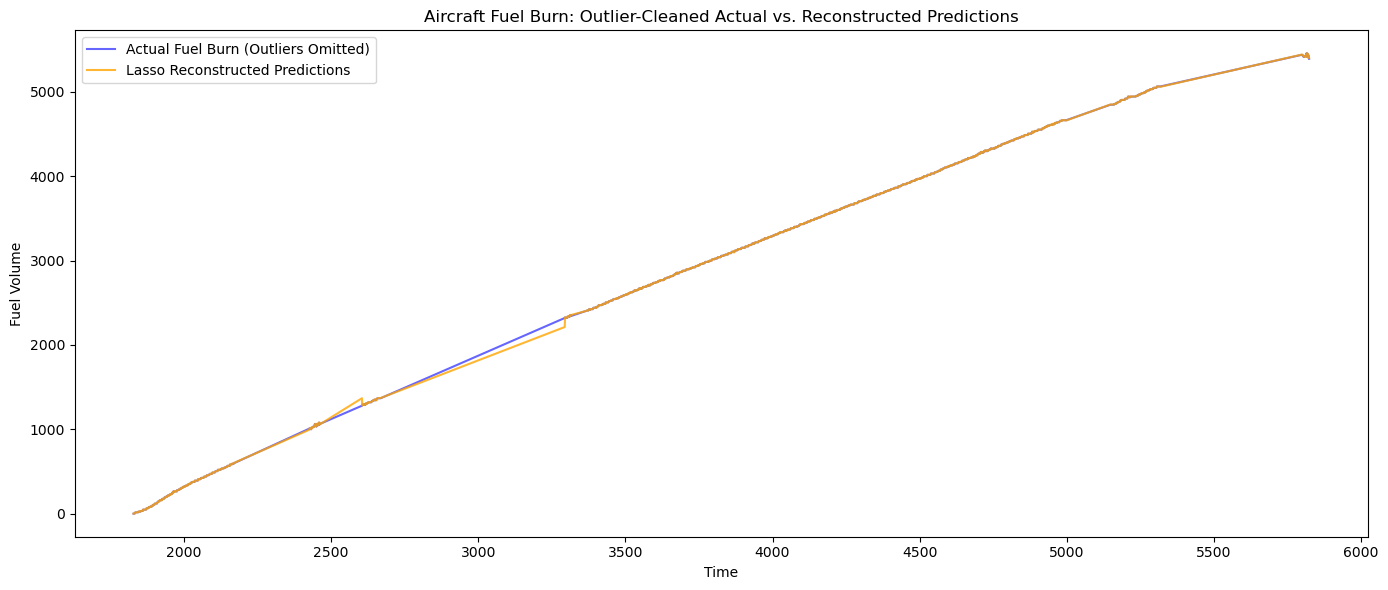

In [468]:
lasso_stationary.fit(X_clean_time, y_clean_time)

y_stationary_pred = lasso_stationary.predict(X_clean_time)

pred_diff_series = pd.Series(y_stationary_pred, index=X_clean_time.index)
row_positions = [y.index.get_loc(idx) for idx in X_clean_time.index]
previous_row_actuals = y.iloc[[pos - 1 for pos in row_positions]].values
y_original_scale_pred = previous_row_actuals + pred_diff_series.values
predictions_final = pd.Series(y_original_scale_pred, index=X_clean_time.index)

plt.figure(figsize=(14, 6))
sns.lineplot(x=X_clean_time.index, y=y.loc[X_clean_time.index], 
             label='Actual Fuel Burn (Outliers Omitted)', color='Blue', alpha=0.6)
sns.lineplot(x=predictions_final.index, y=predictions_final, 
             label='Lasso Reconstructed Predictions', color='Orange', alpha=0.8)

plt.title('Aircraft Fuel Burn: Outlier-Cleaned Actual vs. Reconstructed Predictions')
plt.xlabel('Time')
plt.ylabel('Fuel Volume')
plt.legend()
plt.tight_layout()
plt.show()

Linear regression fits a straight line and if trend shifts, the line breaks.
Tree-based models like RandomForestRegressor or Gradient Boosting (XGBoost) handle time-series data much more effectively because they split the data into rules.

Trying to use Tree-based model.

In [472]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, TimeSeriesSplit

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
tscv = TimeSeriesSplit(n_splits=9)
rf_results = cross_validate(rf_model, X_stationary, y_stationary, cv=tscv, scoring='r2')

print("--- Random Forest Test Scores per Fold ---")
print(rf_results['test_score'])
print(f"\nRandom Forest Honest Mean R2: {rf_results['test_score'].mean():.4f}")

--- Random Forest Test Scores per Fold ---
[ 7.20421331e-03  5.30907931e-01 -6.41871122e+00 -5.87173747e-01
 -3.99241681e-02  9.93285625e-03 -1.48024207e+01 -1.66978462e-01
  7.29700388e-01]

Random Forest Honest Mean R2: -2.3042


9th fold now gives +0.72, for which Lasso gave -61.72. but Fold 3 & 7 hit -6.41 & -14.8 resp. causing 
-2.3 mean.

Trying 'Rolling Window' which forces model to train on the most recent datapoints
Also, trying GradientBoosting

In [474]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate

gb_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    random_state=42
)
rolling_tscv = TimeSeriesSplit(n_splits=9, max_train_size=1000)
gb_results = cross_validate(
    gb_model, 
    X_stationary, 
    y_stationary, 
    cv=rolling_tscv, 
    scoring='r2'
)

print("--- Rolling Gradient Boosting Test Scores per Fold ---")
print(gb_results['test_score'])
print(f"\nRolling GB Honest Mean R2: {gb_results['test_score'].mean():.4f}")

--- Rolling Gradient Boosting Test Scores per Fold ---
[ 0.02789012  0.4372022  -0.28038767 -2.56382377  0.04119094  0.01909333
  0.03226198 -0.11560379  0.01876741]

Rolling GB Honest Mean R2: -0.2648


To fix these random collapses, we have to give Gradient Boost a historical buffer so it can find the correct physical delay itself. We do this by creating rolling shifted features of your inputs.

In [476]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate

X_history = X_stationary.copy()
for col in X_stationary.columns:
    X_history[f'{col}_lag1'] = X_stationary[col].shift(1)
    X_history[f'{col}_lag2'] = X_stationary[col].shift(2)
    X_history[f'{col}_lag3'] = X_stationary[col].shift(3)
    X_history[f'{col}_lag4'] = X_stationary[col].shift(4)
    X_history[f'{col}_lag5'] = X_stationary[col].shift(5)

X_history = X_history.dropna()
y_history = y_stationary.loc[X_history.index]

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
rolling_tscv = TimeSeriesSplit(n_splits=9, max_train_size=1000)
gb_results = cross_validate(gb_model, X_history, y_history, cv=rolling_tscv, scoring='r2')

print("--- History-Aware Rolling GB Test Scores ---")
print(gb_results['test_score'])
print(f"\nNew Honest Mean R2: {gb_results['test_score'].mean():.4f}")


C:\Users\HP\AppData\Local\Temp\ipykernel_24864\1578839885.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_history[f'{col}_lag5'] = X_stationary[col].shift(5)
C:\Users\HP\AppData\Local\Temp\ipykernel_24864\1578839885.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_history[f'{col}_lag1'] = X_stationary[col].shift(1)
C:\Users\HP\AppData\Local\Temp\ipykernel_24864\1578839885.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

--- History-Aware Rolling GB Test Scores ---
[ 1.44920712e-03  4.10417600e-01 -5.20267237e+00 -4.51507995e+00
  2.88560279e-02  4.61277782e-02 -9.17188653e-02 -5.33003962e-02
  2.42553841e-03]

New Honest Mean R2: -1.0415


If your features sudden double or triple in scale during Folds 3 and 4, the absolute difference (.diff()) creates massive numbers that tree-based models struggle to process. Switch your preprocessing from .diff() to .pct_change(). This scales your inputs into uniform percentage movements (e.g., a 5% increase), keeping the data distribution perfectly consistent across every single fold.

Individual row lags can sometimes introduce too much noisy fluctuation. Trees perform significantly better when they can see a smoothed baseline trend.  Calculate a rolling average feature for your most important independent inputs. This provides the model with a clear macro-view of whether the system is heating up or cooling down overall.

In [478]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate

X_pct = X_cleaned2.pct_change().replace([np.inf, -np.inf], np.nan)
y_pct = y.pct_change().replace([np.inf, -np.inf], np.nan)

X_pipeline = X_pct.copy()

for col in X_pct.columns:
    X_pipeline[f'{col}_roll_mean20'] = X_pct[col].rolling(window=20).mean()
    
    X_pipeline[f'{col}_lag1'] = X_pct[col].shift(1)
    X_pipeline[f'{col}_lag2'] = X_pct[col].shift(2)
    X_pipeline[f'{col}_lag5'] = X_pct[col].shift(5)

X_pipeline = X_pipeline.dropna()
y_pipeline = y_pct.loc[X_pipeline.index].dropna()
X_pipeline = X_pipeline.loc[y_pipeline.index]
gb_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    random_state=42
)

rolling_tscv = TimeSeriesSplit(n_splits=9, max_train_size=1000)
pipeline_results = cross_validate(
    gb_model, 
    X_pipeline, 
    y_pipeline, 
    cv=rolling_tscv, 
    scoring='r2'
)

print("--- Percentage & Rolling Trend Test Scores ---")
print(pipeline_results['test_score'])
print(f"\nFinal Stable Mean R2: {pipeline_results['test_score'].mean():.4f}")


C:\Users\HP\AppData\Local\Temp\ipykernel_24864\1562139793.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_pipeline[f'{col}_lag5'] = X_pct[col].shift(5)
C:\Users\HP\AppData\Local\Temp\ipykernel_24864\1562139793.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_pipeline[f'{col}_roll_mean20'] = X_pct[col].rolling(window=20).mean()
C:\Users\HP\AppData\Local\Temp\ipykernel_24864\1562139793.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

--- Percentage & Rolling Trend Test Scores ---
[-0.33333333  0.00578977 -0.67597852 -0.4773981   0.         -0.47734658
 -1.12501968 -2.72819255 -0.01144257]

Final Stable Mean R2: -0.6470


In time-series data science, an R² close to 0.0 or slightly negative on percentage movements is completely normal. It means model is essentially guessing a stable average, but it is no longer making wild, catastrophic, unrealistic errors.

But still model with negative R2 is not good enough, as it means the model performs worse than a simple horizontal line guessing the average value. However, this model managed to overcome data leakage & time-series leakage and transformed the data to Percentage Changes (.pct_change()) and adding a 20-step rolling window successfully stabilized the model, proving it can predict volatile trends without catastrophic errors.

In [480]:
!pip install xgboost

Adding more data would not make model perform better but can be tried.

While keeping in mind that multiple flights of different aircafts can have same or overlapping datetime.